In [1]:
"""
Written by: Tommy Banker (thomas_banker@berkeley.edu)
"""

import os
import json
import numpy as np
import torch
import matplotlib
import matplotlib.pyplot as plt
from utils import *
import seaborn as sns



matplotlib.rcParams.update({# Use mathtext, not LaTeX
                            'text.usetex': False,
                            # Use the Computer modern font
                            'font.family': 'serif',
                            'font.serif': 'cmr10',
                            'mathtext.fontset': 'cm',
                            # Use ASCII minus
                            'axes.unicode_minus': False,
                            'figure.dpi' : 300,

                            })

font = {'weight' : 'bold',
        'size'   : 44}
plt.rc('font', **font)





In [2]:
methods = ['cep', ]
best_list = {'cep': 11.086613 }
best = best_list['cep']
seeds = [0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,]


In [3]:
import pandas as pd

num_list = []
df_g = pd.read_csv('gauche_cep_20.csv')['y1']
for i in range(20):
    str_list = df_g[i].replace('\n','').replace('tensor([','').replace('       ','').replace('], dtype=torch.float64)','').split(', ')

    num_list.append( [float(x) for x in str_list] )


gauche = np.array(num_list)

gauche_m = gauche.mean(axis=0)
gauche_s = gauche.std(axis=0)

In [4]:
!ls 

 adaptive_acq.py		    'New_gauche_MOO_(0_0).csv'
 bo_1_gauche.py			    'New_gauche_MOO_(0_10).csv'
 config				    'New_gauche_MOO_(0_1).csv'
 convergence_cep_constrained.ipynb  'New_gauche_MOO_(0_2).csv'
 convergence_cep_HV.ipynb	    'New_gauche_MOO_(0_3).csv'
 convergence_CEP.ipynb		    'New_gauche_MOO_(0_4).csv'
 convergence_CEPq.ipynb		    'New_gauche_MOO_(0_5).csv'
 convergence_DG.ipynb		    'New_gauche_MOO_(0_6).csv'
 convergence_E.ipynb		    'New_gauche_MOO_(0_7).csv'
 convergence_LIPO.ipynb		    'New_gauche_MOO_(0_8).csv'
 convergence_logp.ipynb		    'New_gauche_MOO_(0_9).csv'
 convergence_malaria.ipynb	    'New_gauche_MOO_(1)_y.csv'
 corr_feature_thinning.py	     __pycache__
 DataFiles			     quinones_dg_e0.csv
 figs				     README.md
 GAUCH-Copy1.ipynb		     UncertaintyAnalysis_CEP.ipynb
 gauche_cep_20.csv		     UncertaintyAnalysis_General.ipynb
 gauche_lipo_20.csv		     UncertaintyAnalysis_lipo.ipynb
 gauche_malaria_20.csv		     UncertaintyAnalysis_malaria.ipynb
 GAUCH.ipynb	

In [5]:
sample_configs = [r'./config/cep/CEP_SAAS_0.json',
                 r'./config/cep/CEP_GP_full_0.json',
                 r'./config/cep/CEP_GP_pca_0.json',
                 r'./config/cep/CEP_Linear_0.json',
                 r'./config/cep/CEP_Random_0.json']


names = ['SAAS','GP_full','GP_PCA', 'Linear' ,'random']
names2 = ['MolDAIS','SGP',"SGP-PCA", 'SLR' ,'Random']

Res_dict_raw = {'SAAS':[], 'GP_full':[],'GP_PCA':[],'Linear':[] , 'random':[]}        
Res_dict_stat = {'SAAS':[], 'GP_full':[],'GP_PCA':[],'Linear':[] , 'random':[]}               
Smi_dict_stat = {'SAAS':[], 'GP_full':[],'GP_PCA':[],'Linear':[] , 'random':[]}                  


end = -1

for i100,sample_config in enumerate(sample_configs):        
    with open(sample_config) as f:
        exp_config = json.load(f)
    ########    
    y_variable = exp_config['common']['y_variable']
    max_min = exp_config['common']['max_min']
    init_budget = exp_config['common']['init_budget']
    total_budget = exp_config['common']['total_budget'] 
    bo_iters = np.arange(1, total_budget - init_budget + 1)
    ########
    all_results = np.zeros((len(methods), len(seeds), total_budget))
    smi_results = []
    sorted_results = np.zeros((len(methods), len(seeds), total_budget - init_budget + 1))
    conv_results = np.zeros((len(methods), (total_budget - init_budget + 1), 2))
    ########
    for i, method in enumerate(methods):
        for j, seed in enumerate(seeds):
            exp_config['exp_name'] = method #+ '_' + str(seed) 
            exp_config['seed'] = seed
            path = os.path.join('../results/', 'cep',)
            if i100==3 : 
                filename = f'cep_max_activity_Linear_seed_{seed}_bo-iter_90_10_to_100_samples_None_None_None'
            #elif i100=4 :
                
            else: 
                filename = get_filename(bo_iters[-1], exp_config).replace('_q_1','')
            result = torch.load(os.path.join(path, filename + '.pkl'))
            all_results[i,j,:] = result['y_train'].squeeze()
            smi_results.append( result['smiles_train'])
    ########
    sorted_results[:,:,0] = np.max(all_results[:,:,:init_budget], axis=2)
    for i, method in enumerate(methods):
        for j, seed in enumerate(seeds):
            for sample in np.arange(total_budget - init_budget + end):
                if all_results[i,j,(init_budget + sample)] > sorted_results[i,j,sample]:
                    sorted_results[i,j,(sample + 1)] = all_results[i,j,(init_budget + sample)]
                else:
                    sorted_results[i,j,(sample + 1)] = sorted_results[i,j,(sample)]
    ########
    for i, method in enumerate(methods):
        for sample in np.arange(total_budget - init_budget + 1+ end):
            conv_results[i,sample,0] = np.mean(sorted_results[i,:,sample])
            conv_results[i,sample,1] = np.std(sorted_results[i,:,sample])
    ########
    sample_numbers = np.arange(total_budget - init_budget + 1)
    #max_min_vars = torch.load('../prop_data/max_min_vars.pkl')
    if max_min == 'max':
        conv_results[:,:,0] = conv_results[:,:,0]#(conv_results[:,:,0]- best  )*-1  #- max_min_vars[y_variable]['max']) * -1
    else:   # convention appears strange bc results as stored are already the
            # negative of the true values to perform minimization experiments
        conv_results[:,:,0] = (conv_results[:,:,0] - -1 * max_min_vars[y_variable]['min']) * -1
    
    
    Res_dict_raw[names[i100]] = sorted_results
    Res_dict_stat[names[i100]] = conv_results    
    Smi_dict_stat[names[i100]] = smi_results

In [45]:


num_list = []
for i in range(20):
    #name = f'./mic_res/results/PCE_sparsity-MIC10_model-GP_acq-EI_iter_90_seed-{i}.pkl'# 10 features
    name = f'./mic_res/results/materntest_PCE_sparsity-CMI10_model-GP_acq-EI_iter_90_seed-{i}.pkl'
    res_i = torch.load(name)
    num_list.append( res_i['best_values']) 
    
micGP = np.array(num_list) 

micGP_m = micGP.mean(axis=0)
micGP_s = micGP.std(axis=0)







num_list = []
for i in range(20):
    name = f'./mic_res/results/PCE_sparsity-MIC10_model-GP_acq-EI_iter_90_seed-{i}.pkl'# 10 features
    #name = f'./mic_res/results/materntest_PCE_sparsity-CMI10_model-GP_acq-EI_iter_90_seed-{i}.pkl'
    res_i = torch.load(name)
    num_list.append( res_i['best_values']) 
    
micGP2 = np.array(num_list) 

micGP_m2 = micGP2.mean(axis=0)
micGP_s2 = micGP2.std(axis=0)





num_list = []
for i in range(10):
    name = f'./mic_res/results/New1_PCE_sparsity-CMI10_model-GP_acq-EI_iter_90_seed-{i}.pkl'# 10 features
    #name = f'./mic_res/results/materntest_PCE_sparsity-CMI10_model-GP_acq-EI_iter_90_seed-{i}.pkl'
    res_i = torch.load(name)
    num_list.append( res_i['best_values']) 
    
micGP3 = np.array(num_list) 

micGP_m3 = micGP3.mean(axis=0)
micGP_s3 = micGP3.std(axis=0)

/tmp/ipykernel_1164613/1124782016.py:31: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.plot(sample_numbers[:end], conv_results[0,:end,0], style, linewidth=3, label=names2[i], c=colors[i], alpha=a1)


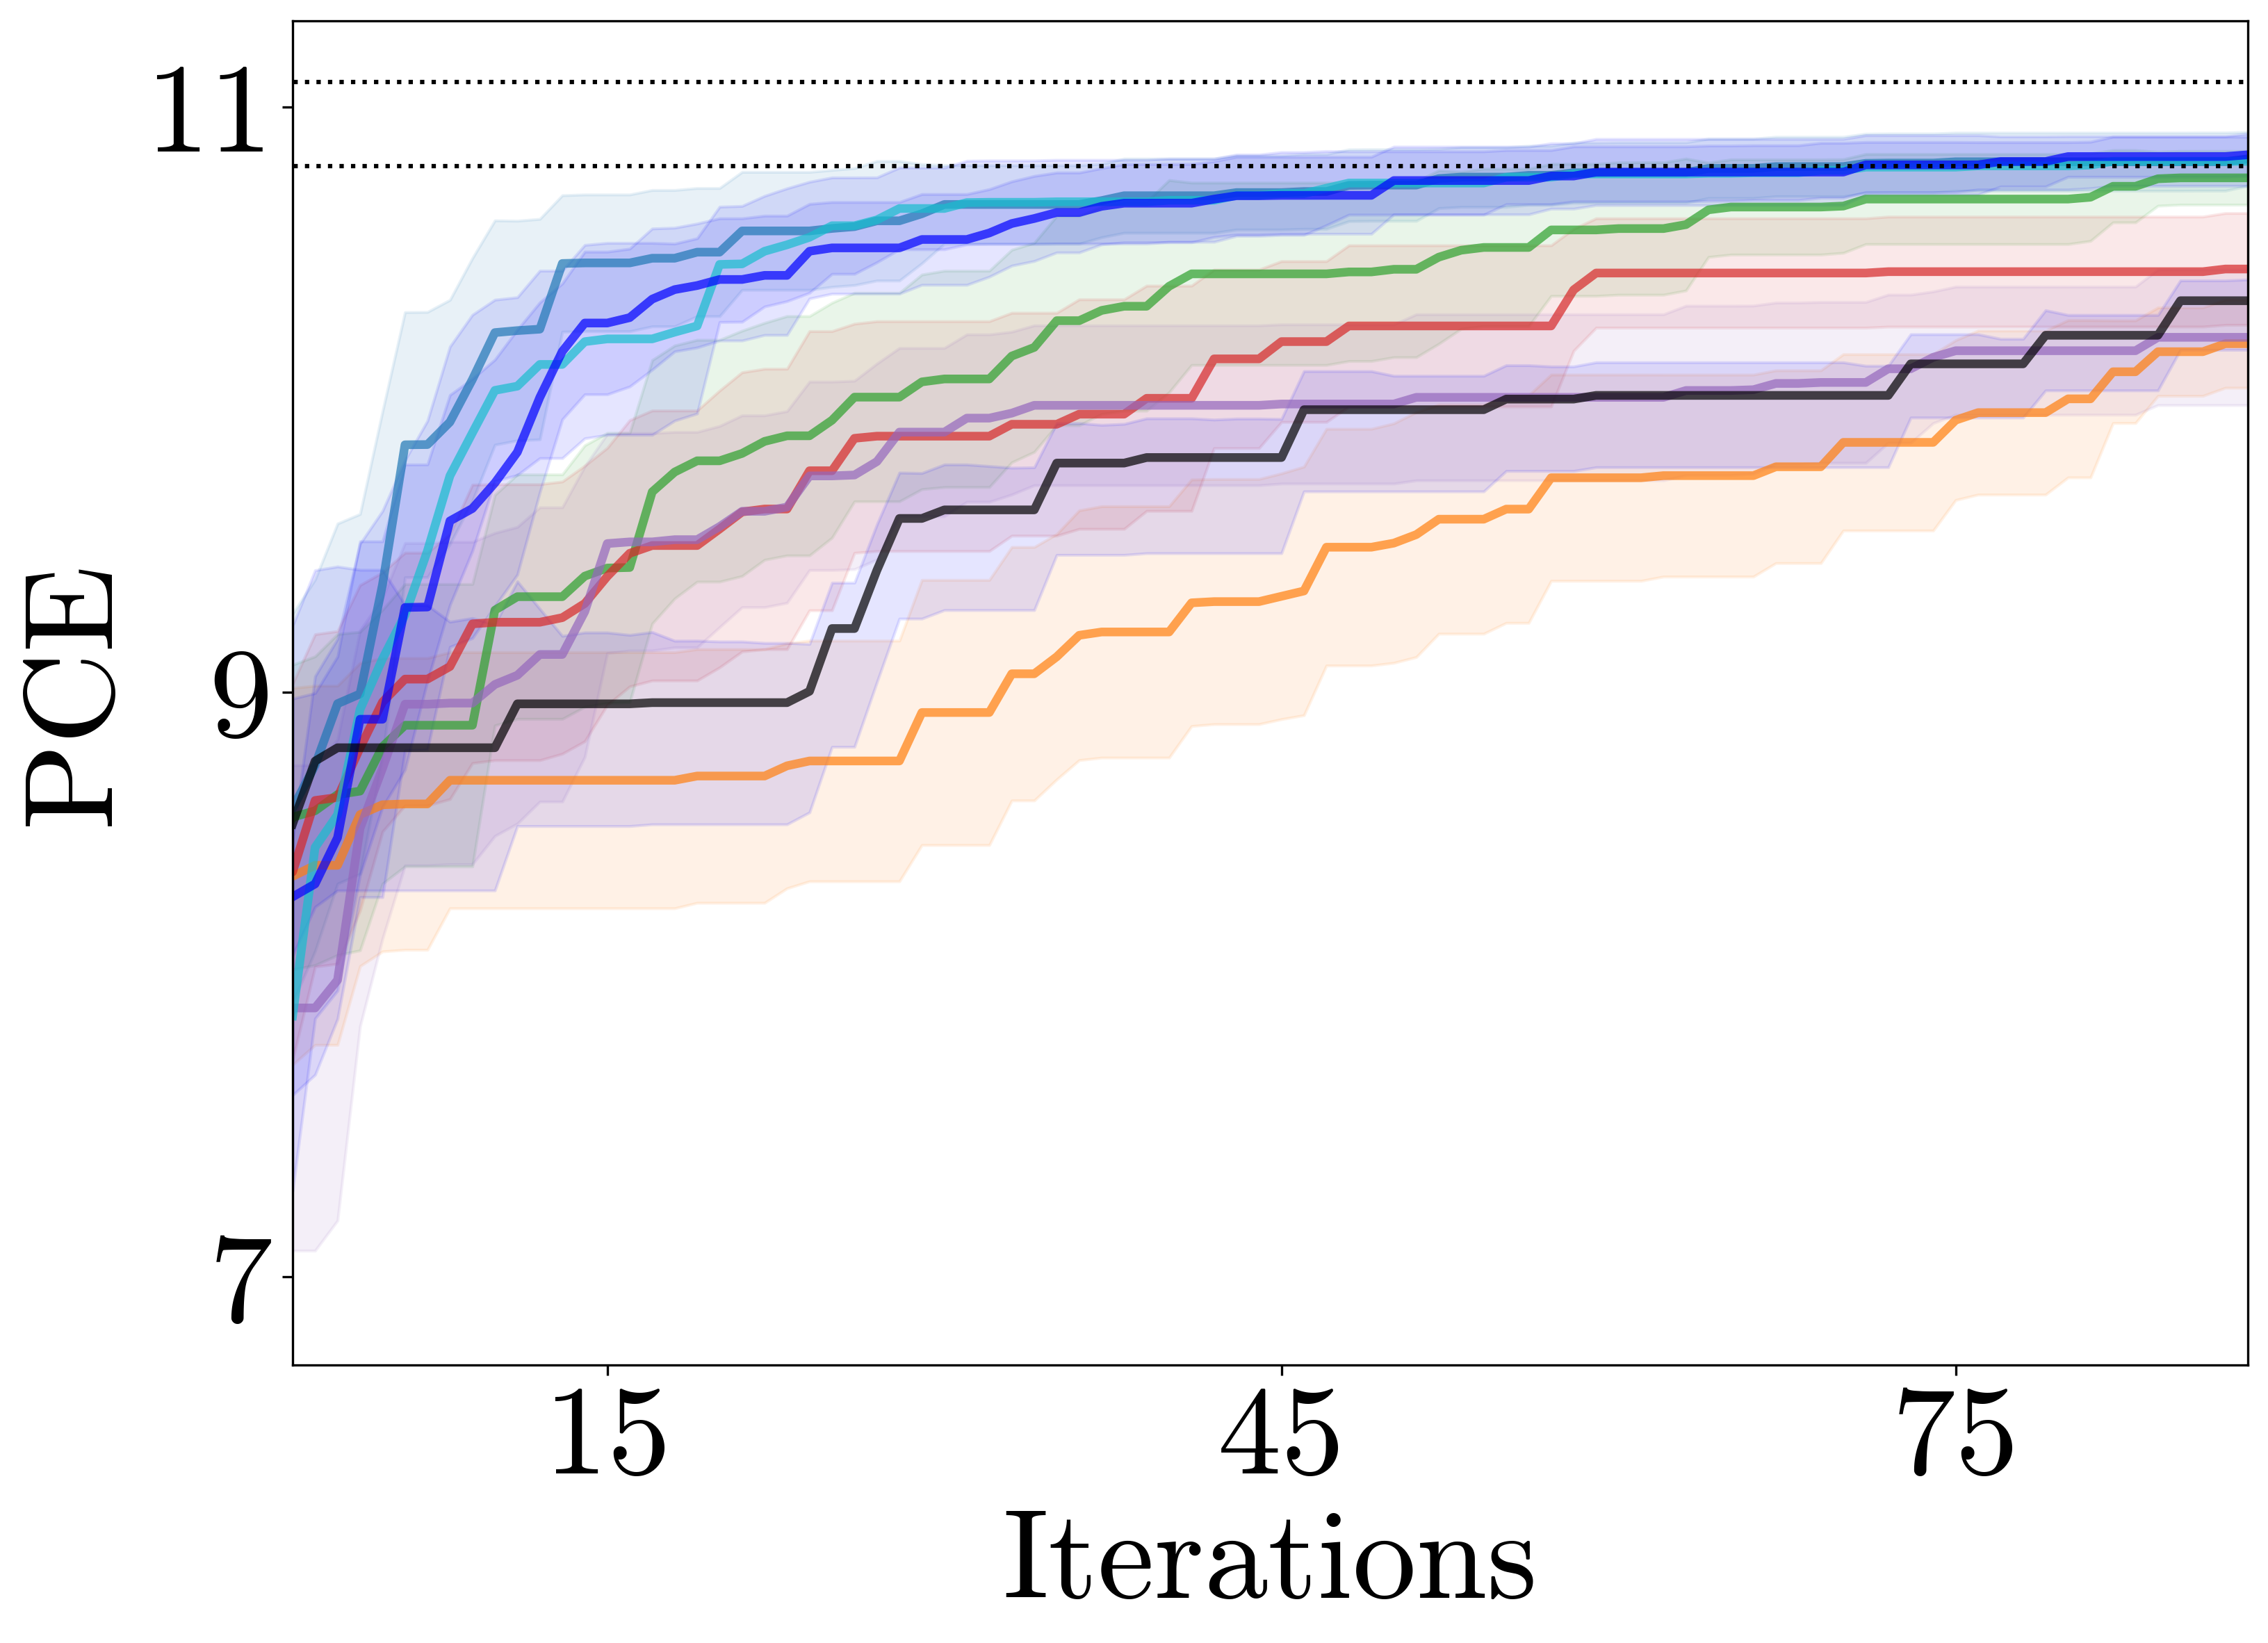

In [46]:
#colors = [c for c in mcolors.TABLEAU_COLORS]
from matplotlib import gridspec

colors = ['tab:blue',

 'tab:orange',
 'tab:green',
 'tab:red',
 'tab:purple',

  'tab:cyan',
  'blue',
         ]


#colors =  ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',  '#9467bd', '#7f7f7f', '#bcbd22', '#17becf']
names = ['SAAS','GP_full','GP_PCA', 'random']
names2 = ['MolDAIS-SAAS','SGP',"SGP-PCA", 'Random']

a1 = .7
a2 = .1
gs = gridspec.GridSpec(1, 6)

fig = plt.figure(figsize=(12,9),)

#ax1 = plt.subplot(gs[0,0:4])
for i, method in enumerate(names):
    style = '-'
    conv_results = Res_dict_stat[method]
    
    plt.plot(sample_numbers[:end], conv_results[0,:end,0], style, linewidth=3, label=names2[i], c=colors[i], alpha=a1)
    plt.fill_between(sample_numbers[:end], conv_results[0,:end,0]-(1.95*conv_results[0,:end,1]/(len(seeds)**0.5)), conv_results[0,:end,0]+(1.95*conv_results[0,:end,1]/(len(seeds)**0.5)), alpha=a2, color=colors[i])

plt.plot(sample_numbers, gauche_m, style, linewidth=3, label='TM-FP', c=colors[i+1], alpha=a1)
plt.fill_between(sample_numbers, gauche_m-(1.95*gauche_s/(len(seeds)**0.5)), gauche_m+(1.95*gauche_s/(len(seeds)**0.5)), alpha=a2, color=colors[i+1])

plt.plot(sample_numbers[1:], micGP_m, '-', linewidth=3, label='MolDAIS-MI', c=colors[-2], alpha=a1)
plt.fill_between(sample_numbers[1:], micGP_m-(1.95*micGP_s/(len(seeds)**0.5)), micGP_m+(1.95*micGP_s/(len(seeds)**0.5)), alpha=a2, color=colors[-1])

plt.plot(sample_numbers[1:], micGP_m2, '-', linewidth=3, label='MolDAIS-MIC', c=colors[-1], alpha=a1)
plt.fill_between(sample_numbers[1:], micGP_m2-(1.95*micGP_s2/(len(seeds)**0.5)), micGP_m2+(1.95*micGP_s2/(len(seeds)**0.5)), alpha=a2, color=colors[-1])

plt.plot(sample_numbers[1:], micGP_m3, '-', linewidth=3, label='MolDAIS-CMI', c='k', alpha=a1)
plt.fill_between(sample_numbers[1:], micGP_m3-(1.95*micGP_s3/(len(seeds)**0.5)), micGP_m3+(1.95*micGP_s2/(len(seeds)**0.5)), alpha=a2, color=colors[-1])




plt.plot([0,90],[best,best],'k:')
plt.plot([0,90],[10.8,10.8],'k:')


#plt.legend(fontsize=24, ncols=3, loc='lower center',bbox_to_anchor=(.5,1))
#plt.title('Convergence Results Across ' + str(len(seeds)) + ' Runs with ' + str(init_budget) + ' Initial Random Samples')
plt.xlabel('Iterations')
plt.ylabel('PCE' )
#plt.yscale('log')
plt.xlim(1,88)    
plt.xticks([15,45,75])
plt.yticks([7,9,11])

#ax2 = plt.subplot(gs[0,4:], )
#plt.hist(data, orientation='horizontal', density=True, alpha=0.0)
#sns.kdeplot(df['y1'].to_numpy(), vertical=True, ax = ax2, cumulative=True)    
# Remove x ticks
#plt.tick_params(axis='x', which='both', bottom=False, top=False, labelbottom=False)
# Remove y ticks
#plt.tick_params(axis='y', which='both', left=False, right=False, labelleft=False)
#ax2.set_xlabel('')  
#ax2.set_ylim(data.min(), data.max())
plt.tight_layout()
plt.savefig('./figs/cep/Convergence.png')
    
 

In [249]:
data =  df['y1'].to_numpy()
data.max()

11.086613

In [76]:

for i, method in enumerate(names):
    conv_results = Res_dict_stat[method]
    print(method, ' : ', conv_results[0,-2,0].item())
print('MIC : ', micGP_m[-1])

SAAS  :  10.833268404006958
GP_full  :  10.222613620758057
GP_PCA  :  10.786264753341674
Linear  :  10.510386180877685
random  :  10.446910381317139
MIC :  10.315316820144654


/tmp/ipykernel_3650194/893879644.py:57: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  hist = plt.hist(df['y1'],bins=int(len(df['y1'])/100))
/tmp/ipykernel_3650194/893879644.py:59: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  fig, ax = plt.subplots(figsize=(12,9))


IndexError: list index out of range

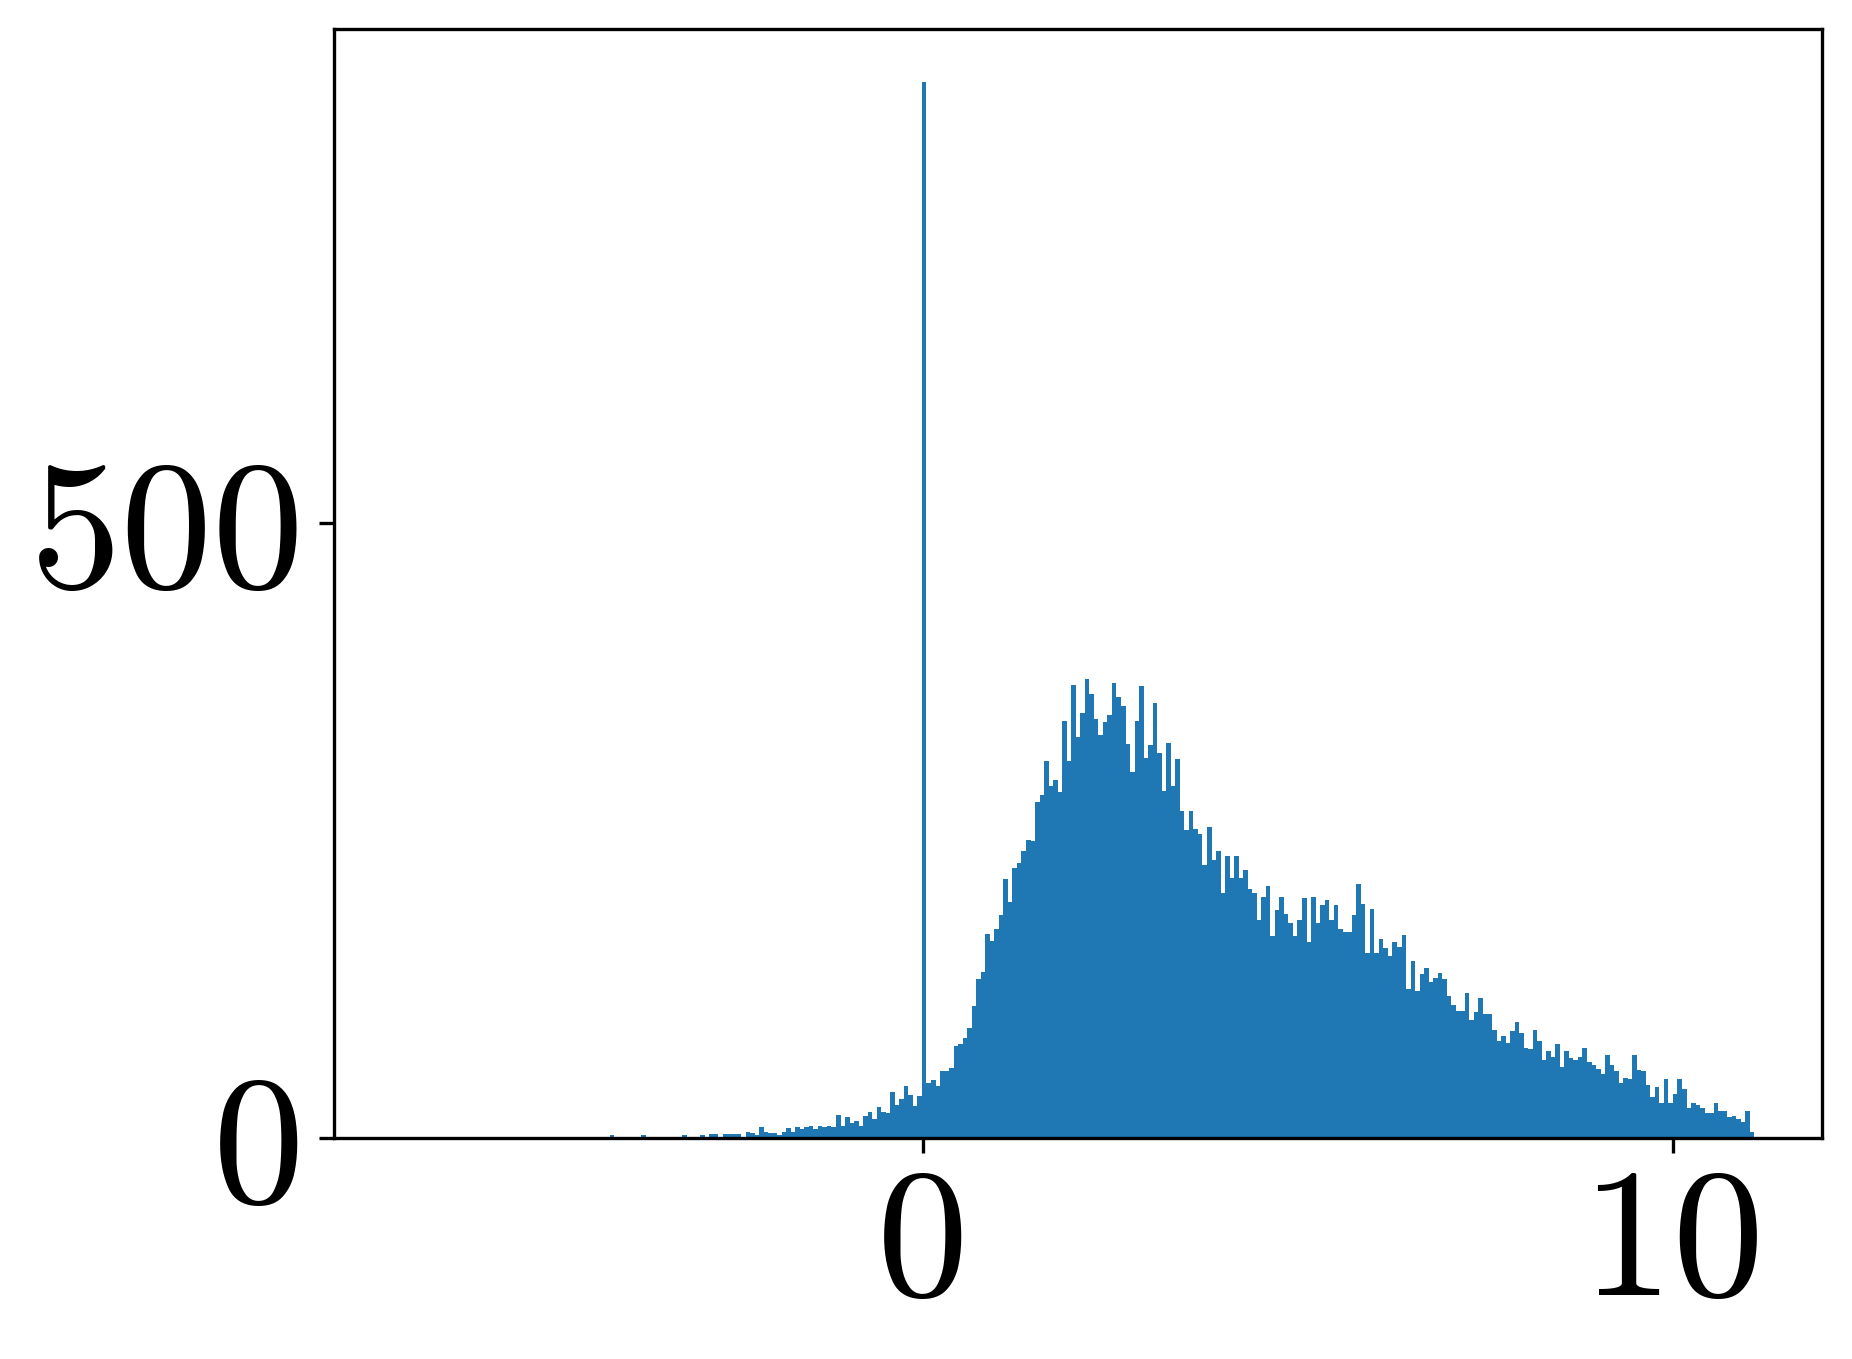

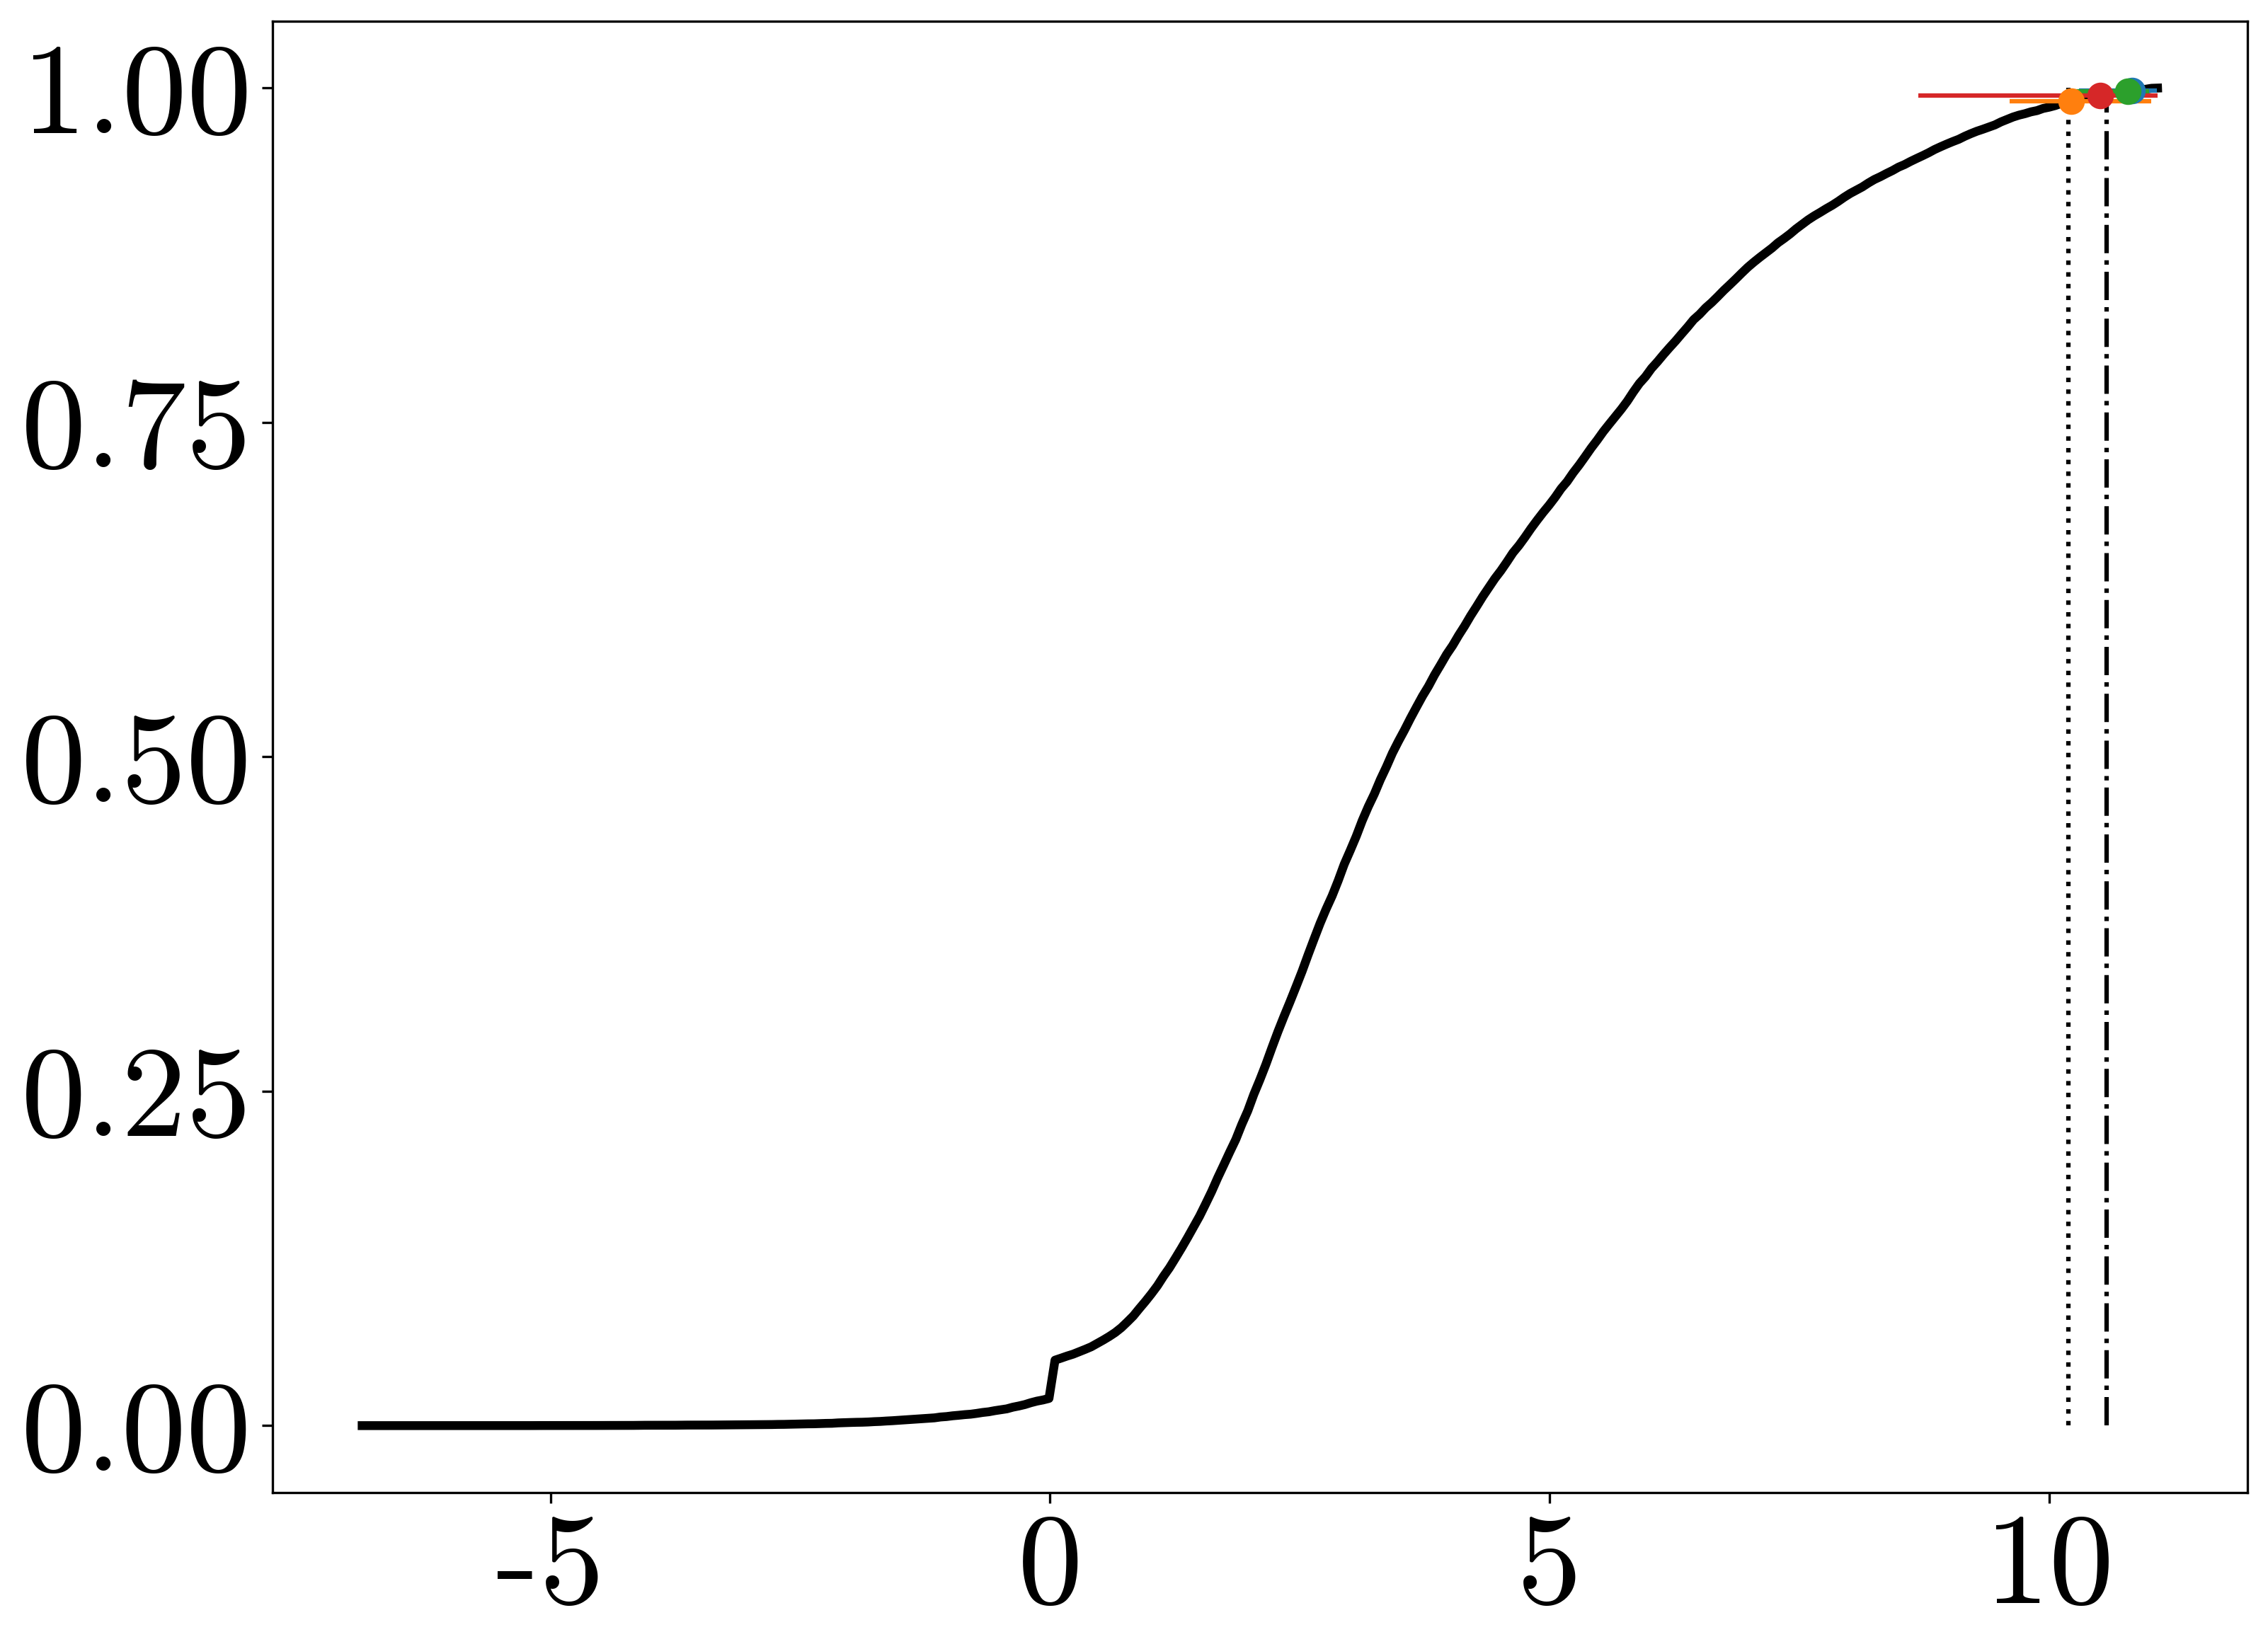

In [42]:
from scipy.stats import percentileofscore

end=-2
sorted_results = Res_dict_raw['SAAS']
Res_dict_stat['SAAS']
best_found = (sorted_results[0,:,end].max() )#- dmax)*-1 
worst_found = (sorted_results[0,:,end].min())# - dmax)*-1 
mean_found = (sorted_results[0,:,end].mean() )#- dmax)*-1 

sorted_results = Res_dict_raw['GP_full']
Res_dict_stat['GP_full']
best_found2 = (sorted_results[0,:,end].max() )#- dmax)*-1 
worst_found2 = (sorted_results[0,:,end].min() )#- dmax)*-1 
mean_found2 = (sorted_results[0,:,end].mean() )#- dmax)*-1 


sorted_results = Res_dict_raw['GP_PCA']
Res_dict_stat['GP_PCA']
best_found3 = (sorted_results[0,:,end].max() )#- dmax)*-1 
worst_found3 = (sorted_results[0,:,end].min() )#- dmax)*-1 
mean_found3 = (sorted_results[0,:,end].mean() )#- dmax)*-1 


sorted_results = Res_dict_raw['Linear']
Res_dict_stat['Linear']
best_found4 = (sorted_results[0,:,end].max() )#- dmax)*-1 
worst_found4 = (sorted_results[0,:,end].min() )#- dmax)*-1 
mean_found4 = (sorted_results[0,:,end].mean() )#- dmax)*-1 


sorted_results = Res_dict_raw['random']
Res_dict_stat['random']
best_found5 = (sorted_results[0,:,end].max() )#- dmax)*-1 
worst_found5 = (sorted_results[0,:,end].min() )#- dmax)*-1 
mean_found5 = (sorted_results[0,:,end].mean() )#- dmax)*-1 




df = pd.read_csv('../prop_data/MORDRED_SMILES_cep_PCE.csv')
dmin, dmax = df['y1'].min(), df['y1'].max()


ms = 8
cs = 8

import matplotlib.patches as patches
inp = torch.tensor(df['y1'].to_numpy())
quantile = .99

act_quant = percentileofscore(df['y1'].to_list(),mean_found)/100
act_quant2 = percentileofscore(df['y1'].to_list(),mean_found2)/100
act_quant3 = percentileofscore(df['y1'].to_list(),mean_found3)/100
act_quant4 = percentileofscore(df['y1'].to_list(),mean_found4)/100
act_quant5 = percentileofscore(df['y1'].to_list(),mean_found5)/100

hist = plt.hist(df['y1'],bins=int(len(df['y1'])/100))

fig, ax = plt.subplots(figsize=(12,9))
count, bins_count = hist[0], hist[1]
pdf = count / sum(count)
cdf = np.cumsum(pdf)
plt.plot(bins_count[1:], cdf, label="CDF", linewidth=3, color='k')
plt.vlines(torch.quantile(inp,quantile) , 0,1, color='k', linestyle=':', label= f'{quantile*100:.1f}% quantile')
plt.vlines(torch.quantile(inp,.995) , 0,1, color='k', linestyle='-.', label= f'{.995*100:.1f}% quantile')
plt.errorbar([mean_found], [act_quant],   xerr=np.array([[np.abs(mean_found-worst_found),np.abs(best_found-mean_found)]]).reshape(2,1),      color=colors[0], marker='o', label= names2[0], markersize=ms)
plt.errorbar([mean_found2], [act_quant2], xerr=np.array([[np.abs(mean_found2-worst_found2),np.abs(best_found2-mean_found2)]]).reshape(2,1),  color=colors[1], marker='o', label= names2[1], markersize=ms)
plt.errorbar([mean_found3], [act_quant3], xerr=np.array([[np.abs(mean_found3-worst_found3),np.abs(best_found3-mean_found3)]]).reshape(2,1),  color=colors[2], marker='o', label= names2[2], markersize=ms)
plt.errorbar([mean_found4], [act_quant4], xerr=np.array([[np.abs(mean_found4-worst_found4),np.abs(best_found4-mean_found4)]]).reshape(2,1),  color=colors[3], marker='o', label= names2[3], markersize=ms)
plt.errorbar([mean_found5], [act_quant5], xerr=np.array([[np.abs(mean_found5-worst_found5),np.abs(best_found5-mean_found5)]]).reshape(2,1),  color=colors[4], marker='o', label= names2[4], markersize=ms)
plt.legend(ncols=2, fontsize=26, loc = 2)
plt.savefig('./figs/lipo/CDF_quantiles.png')



ms = 12
cs = 12

fig, ax = plt.subplots(figsize=(12,9))
count, bins_count = hist[0], hist[1]
pdf = count / sum(count)
cdf = np.cumsum(pdf)
plt.plot(bins_count[1:], cdf, label="CDF", linewidth=3, color='k')
plt.vlines(torch.quantile(inp,quantile) , 0,1, color='k', linestyle=':', label= f'{quantile*100:.1f}% quantile')
plt.vlines(torch.quantile(inp,.995) , 0,1, color='k', linestyle='-.', label= f'{.995*100:.1f}% quantile')
plt.errorbar([mean_found], [act_quant],   xerr=np.array([[np.abs(mean_found-worst_found),np.abs(best_found-mean_found)]]).reshape(2,1),      color=colors[0], marker='o', label= names2[0], markersize=ms,capsize=10)
plt.errorbar([mean_found2], [act_quant2], xerr=np.array([[np.abs(mean_found2-worst_found2),np.abs(best_found2-mean_found2)]]).reshape(2,1),  color=colors[1], marker='o', label= names2[1], markersize=ms,capsize=10)
plt.errorbar([mean_found3], [act_quant3], xerr=np.array([[np.abs(mean_found3-worst_found3),np.abs(best_found3-mean_found3)]]).reshape(2,1),  color=colors[2], marker='o', label= names2[2], markersize=ms,capsize=10)
plt.errorbar([mean_found4], [act_quant4], xerr=np.array([[np.abs(mean_found4-worst_found4),np.abs(best_found4-mean_found4)]]).reshape(2,1),  color=colors[3], marker='o', label= names2[3], markersize=ms,capsize=10)
plt.errorbar([mean_found5], [act_quant5], xerr=np.array([[np.abs(mean_found5-worst_found5),np.abs(best_found5-mean_found5)]]).reshape(2,1),  color=colors[4], marker='o', label= names2[4], markersize=ms,capsize=10)
plt.legend(loc='lower left',ncols=2, fontsize=26)
#plt.xscale("log")
plt.xlim(dmax-0.8, dmax+.01)
plt.ylim(.985,1.0)
plt.savefig('./figs/lipo/CDF_quantiles_zoom.png')


In [ ]:
df = pd.read_csv('../prop_data/MORDRED_SMILES_cep_PCE.csv')
dmin, dmax = df['y1'].min(), df['y1'].max()

sorted_results = Res_dict_raw['SAAS']
Res_dict_stat['SAAS']
best_found = sorted_results[0,:,end]

sorted_results = Res_dict_raw['GP_full']
Res_dict_stat['GP_full']
best_found2 = sorted_results[0,:,end]

sorted_results = Res_dict_raw['GP_PCA']
Res_dict_stat['GP_PCA']
best_found3 = sorted_results[0,:,end]

sorted_results = Res_dict_raw['Linear']
Res_dict_stat['Linear']
best_found4 = sorted_results[0,:,end]

sorted_results = Res_dict_raw['random']
Res_dict_stat['random']
best_found5 = sorted_results[0,:,end]



count, bins_count = hist[0], hist[1]
hist = plt.hist(df['y1'],bins=int(len(df['y1'])/10))

bins = np.linspace(4,dmax+.01,1000)

fig, ax = plt.subplots(figsize=(12,9))
plt.hist(best_found,bins=bins, alpha=.3,label='MolDAIS')
plt.hist(best_found2,bins=bins,alpha=.3,label='SGP')
plt.hist(best_found3,bins=bins,alpha=.3,label='PCA-SGP')
plt.hist(best_found4,bins=bins,alpha=.3,label='SLS')
plt.hist(best_found5,bins=bins,alpha=.3,label='Random')
plt.hist(df['activity'],bins=bins_count[1:],alpha=.2, color='gray')
plt.legend()

fig, ax = plt.subplots(figsize=(12,9))
hist1 = plt.hist(best_found,bins=bins, alpha=.3,label='MolDAIS')
hist2 = plt.hist(best_found2,bins=bins,alpha=.3,label='SGP')
hist3 = plt.hist(best_found3,bins=bins,alpha=.3,label='PCA-SGP')
hist4 = plt.hist(best_found4,bins=bins,alpha=.3,label='SLS')
hist5 = plt.hist(best_found5,bins=bins,alpha=.3,label='Random')
#plt.hist(df['activity'],bins=bins_count[1:],alpha=.2, color='gray')
plt.legend()
#plt.xlim(0,3)
#plt.ylim(0,len(seeds)+1)

hist6 = plt.hist(best_found5*0+dmax, bins = bins)

fig, ax = plt.subplots(figsize=(12,9))
plt.step(hist1[1][1:],np.cumsum(hist1[0]),marker='o', alpha=1,label='MolDAIS')
plt.step(hist2[1][1:],np.cumsum(hist2[0]),marker='o', alpha=1,label='SGP')
plt.step(hist3[1][1:],np.cumsum(hist3[0]),marker='o', alpha=1,label='PCA-SGP')
plt.step(hist4[1][1:],np.cumsum(hist4[0]),marker='o', alpha=1,label='SLS')
plt.step(hist5[1][1:],np.cumsum(hist5[0]),marker='o', alpha=1,label='Random')
plt.step(hist6[1][1:],np.cumsum(hist6[0]), 'k:', alpha=1,label='Ideal')
#plt.hist(df['activity'],bins=bins_count[1:],alpha=.2, color='gray')
plt.legend()
plt.xlim(4,dmax+0.01)
#plt.ylim(0,len(seeds)+1)




In [186]:
inp = torch.tensor(df['activity'].to_numpy())
torch.quantile(inp,.995),torch.quantile(inp,.997),torch.quantile(inp,.999) 

(tensor(4.3701, dtype=torch.float64),
 tensor(4.4200, dtype=torch.float64),
 tensor(4.4900, dtype=torch.float64))

In [222]:
np.cumsum(hist6[0])

array([ 0.,  0.,  0.,  0.,  0., 20., 20., 20., 20., 20.])

In [188]:
worst_found,mean_found , best_found

(4.25,
 4.4249999761581424,
 array([4.48999977, 4.48000002, 4.34000015, 4.48000002, 4.5       ,
        4.38000011, 4.30999994, 4.48000002, 4.3499999 , 4.42000008,
        4.48999977, 4.25      , 4.42999983, 4.5       , 4.48999977,
        4.4000001 , 4.3499999 , 4.4000001 , 4.48000002, 4.48000002]))

In [10]:
# plot molecule sample sequence
import rdkit as rd
from rdkit.Chem import Draw

bestsmis = df['SMILES'][df['y1']>=4.5].to_list()


sorted_results1 = Res_dict_raw['SAAS']
sorted_results2 = Res_dict_raw['GP_full']
sorted_results3 = Res_dict_raw['GP_PCA']
sorted_results4 = Res_dict_raw['Linear']

idx = 4




set1 = sorted_results1[0,idx,:]
set2 = sorted_results2[0,idx,:]
set3 = sorted_results3[0,idx,:]
set4 = sorted_results4[0,idx,:]

smis1 = Smi_dict_stat['SAAS'][idx]
smis2 = Smi_dict_stat['GP_full'][idx]
smis3 = Smi_dict_stat['GP_PCA'][idx]
smis4 = Smi_dict_stat['Linear'][idx]


smi1 = []
smi2 = []
smi3 = []
smi4 = []
m1, m2, m3, m4 = set1[0],  set2[0], set3[0], set4[0]

idx_list1 = []
idx_list2 = []
idx_list3 = []
idx_list4 = []

for i in sample_numbers[1:]:
    
    i1 = set1[:i].max()
    i2 = set2[:i].max()
    i3 = set3[:i].max()
    i4 = set4[:i].max()

    
    if i1>m1 or smis1[i] in bestsmis:
        smi1.append(rd.Chem.MolFromSmiles(smis1[i]))
        m1 = i1
        idx_list1.append([i, i1])
        
    if i2>m2 or smis2[i] in bestsmis:
        smi2.append(rd.Chem.MolFromSmiles(smis2[i]))
        m2 = i2
        idx_list2.append([i,i2])        
        
    if i3>m3 or smis3[i] in bestsmis:
        smi3.append(rd.Chem.MolFromSmiles(smis3[i]))
        m3 = i3
        idx_list3.append([i,i3])        
            
    if i4>m4 or smis4[i] in bestsmis:
        smi4.append(rd.Chem.MolFromSmiles(smis4[i]))
        m4 = i4
        idx_list4.append([i,i4])      


In [252]:
legend=['Itr: '+ str(x[0])+'  =  '+f" {x[1]:.3f}" for x in idx_list1]
print("MolDAIS")
img = rd.Chem.Draw.MolsToGridImage(smi1,molsPerRow=5,subImgSize=(500,500),useSVG=False,legends=legend)

png = img.data
with open('./figs/malaria/mols_SAAS.png','wb+') as outf:
    outf.write(png)

MolDAIS


In [253]:
legend=['Itr: '+ str(x[0])+'  =  '+f" {x[1]:.3f}" for x in idx_list2]
print("SBO-PCA")
img = rd.Chem.Draw.MolsToGridImage(smi2,molsPerRow=5,subImgSize=(500,500),useSVG=False,legends=legend)

png = img.data
with open('./figs/malaria/mols_SBOPCAt.png','wb+') as outf:
    outf.write(png)

SBO-PCA


In [254]:
legend=['Itr: '+ str(x[0])+'  =  '+f" {x[1]:.3f}" for x in idx_list4]
print('SLR')
img = rd.Chem.Draw.MolsToGridImage(smi4,molsPerRow=5,subImgSize=(500,500),useSVG=False,legends=legend)

png = img.data
with open('./figs/malaria/mols_SLR.png','wb+') as outf:
    outf.write(png)

SLR


In [255]:
legend=['Itr: '+ str(x[0])+'  =  '+f" {x[1]:.3f}" for x in idx_list3]
print('SBO')
img = rd.Chem.Draw.MolsToGridImage(smi3,molsPerRow=5,subImgSize=(500,500),useSVG=False,legends=legend)

png = img.data
with open('./figs/malaria/mols_SBO.png','wb+') as outf:
    outf.write(png)

SBO


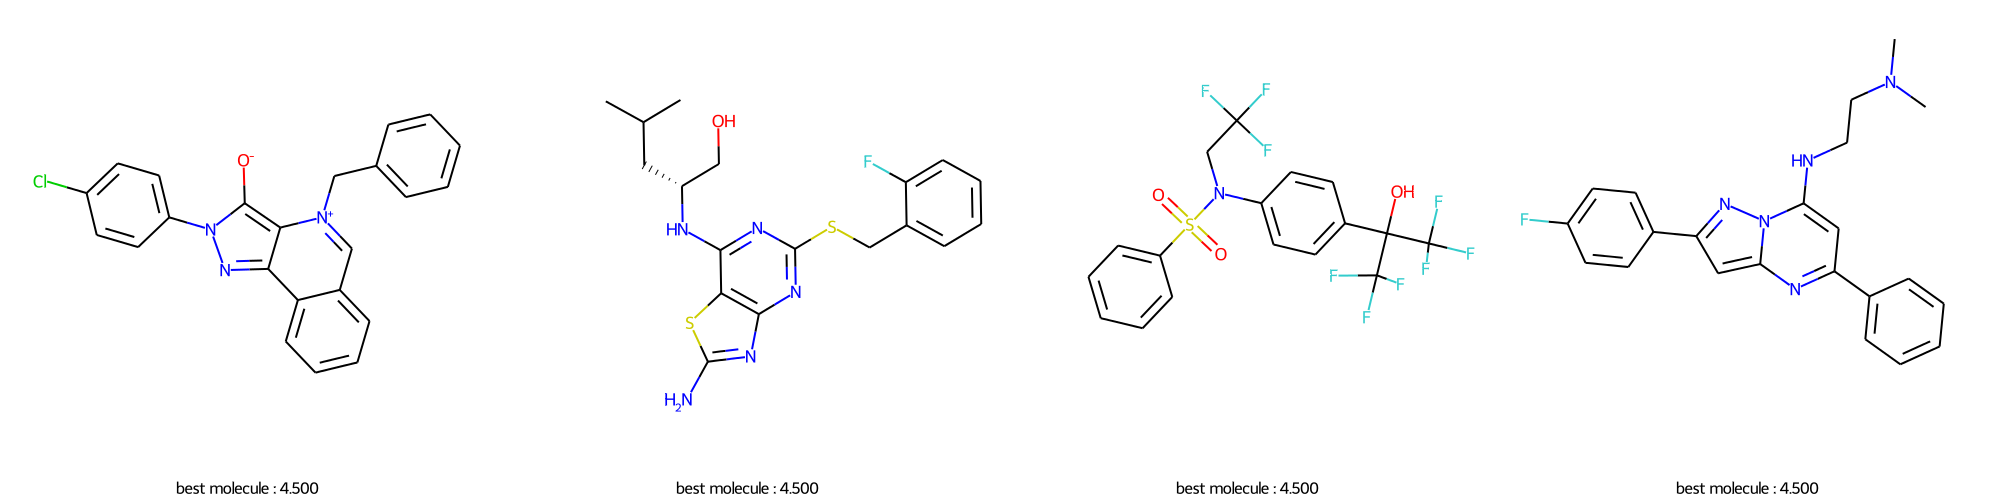

In [256]:
bestsmis = df['SMILES'][df['activity']>=best].to_list()
bestmol=[]
for i in bestsmis: 
    bestmol.append(rd.Chem.MolFromSmiles( i))
bestval =  df['activity'][df['activity']>=best].to_list()
legend = [f"best molecule : {bestval[i]:.3f}" for i in range(len(bestval))]

img = rd.Chem.Draw.MolsToGridImage(bestmol,molsPerRow=5,subImgSize=(500,500),useSVG=False,legends=legend)



png = img.data
with open('./figs/malaria/mols_best.png','wb+') as outf:
    outf.write(png)
    
rd.Chem.Draw.MolsToGridImage(bestmol,molsPerRow=4,subImgSize=(500,500),useSVG=False,legends=legend)


In [195]:
legend

['best molecule : 4.500',
 'best molecule : 4.500',
 'best molecule : 4.500',
 'best molecule : 4.500']

In [196]:

rr1= []
for k,i in enumerate(smis1):
    if i in  df['SMILES'].to_list():
        rr1.append(df[df['SMILES']==i]['activity'].item())
        
rr2= []
for k,i in enumerate(smis2):
    if i in  df['SMILES'].to_list():
        rr2.append(df[df['SMILES']==i]['activity'].item())
        
rr4= []
for k,i in enumerate(smis4):
    if i in  df['SMILES'].to_list():
        rr4.append(df[df['SMILES']==i]['activity'].item())
        
rr3= []
for k,i in enumerate(smis3):
    if i in  df['SMILES'].to_list():
        rr3.append(df[df['SMILES']==i]['activity'].item())
        
        
print(np.array(rr1).max())
print(np.array(rr2).max())
print(np.array(rr4).max())
print(np.array(rr3).max())

4.5
4.25
4.5
4.31


In [197]:
np.array(df['activity'].to_list()).min()#[df['activity']>=11.]

-1.5

In [156]:
print(sorted_results1[0,:,-1])
print(sorted_results2[0,:,-1])
print(sorted_results3[0,:,-1])
print(sorted_results4[0,:,-1])
sorted_results1.shape

[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]


(1, 20, 91)

In [153]:
micGP[:,end], dmax, dmin
sorted_results5[0,:,end]

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0.])

In [28]:
import numpy as np
from scipy import stats

def CQ(results, y):
    y_sorted = np.sort(y)
    quantiles = np.array([stats.percentileofscore(y_sorted, x) / 100 for x in results])
    return quantiles



/tmp/ipykernel_1164613/1504237912.py:76: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.axvline(i, color=C[i], linestyle='-', zorder=0, linewidth=102, alpha=.15)


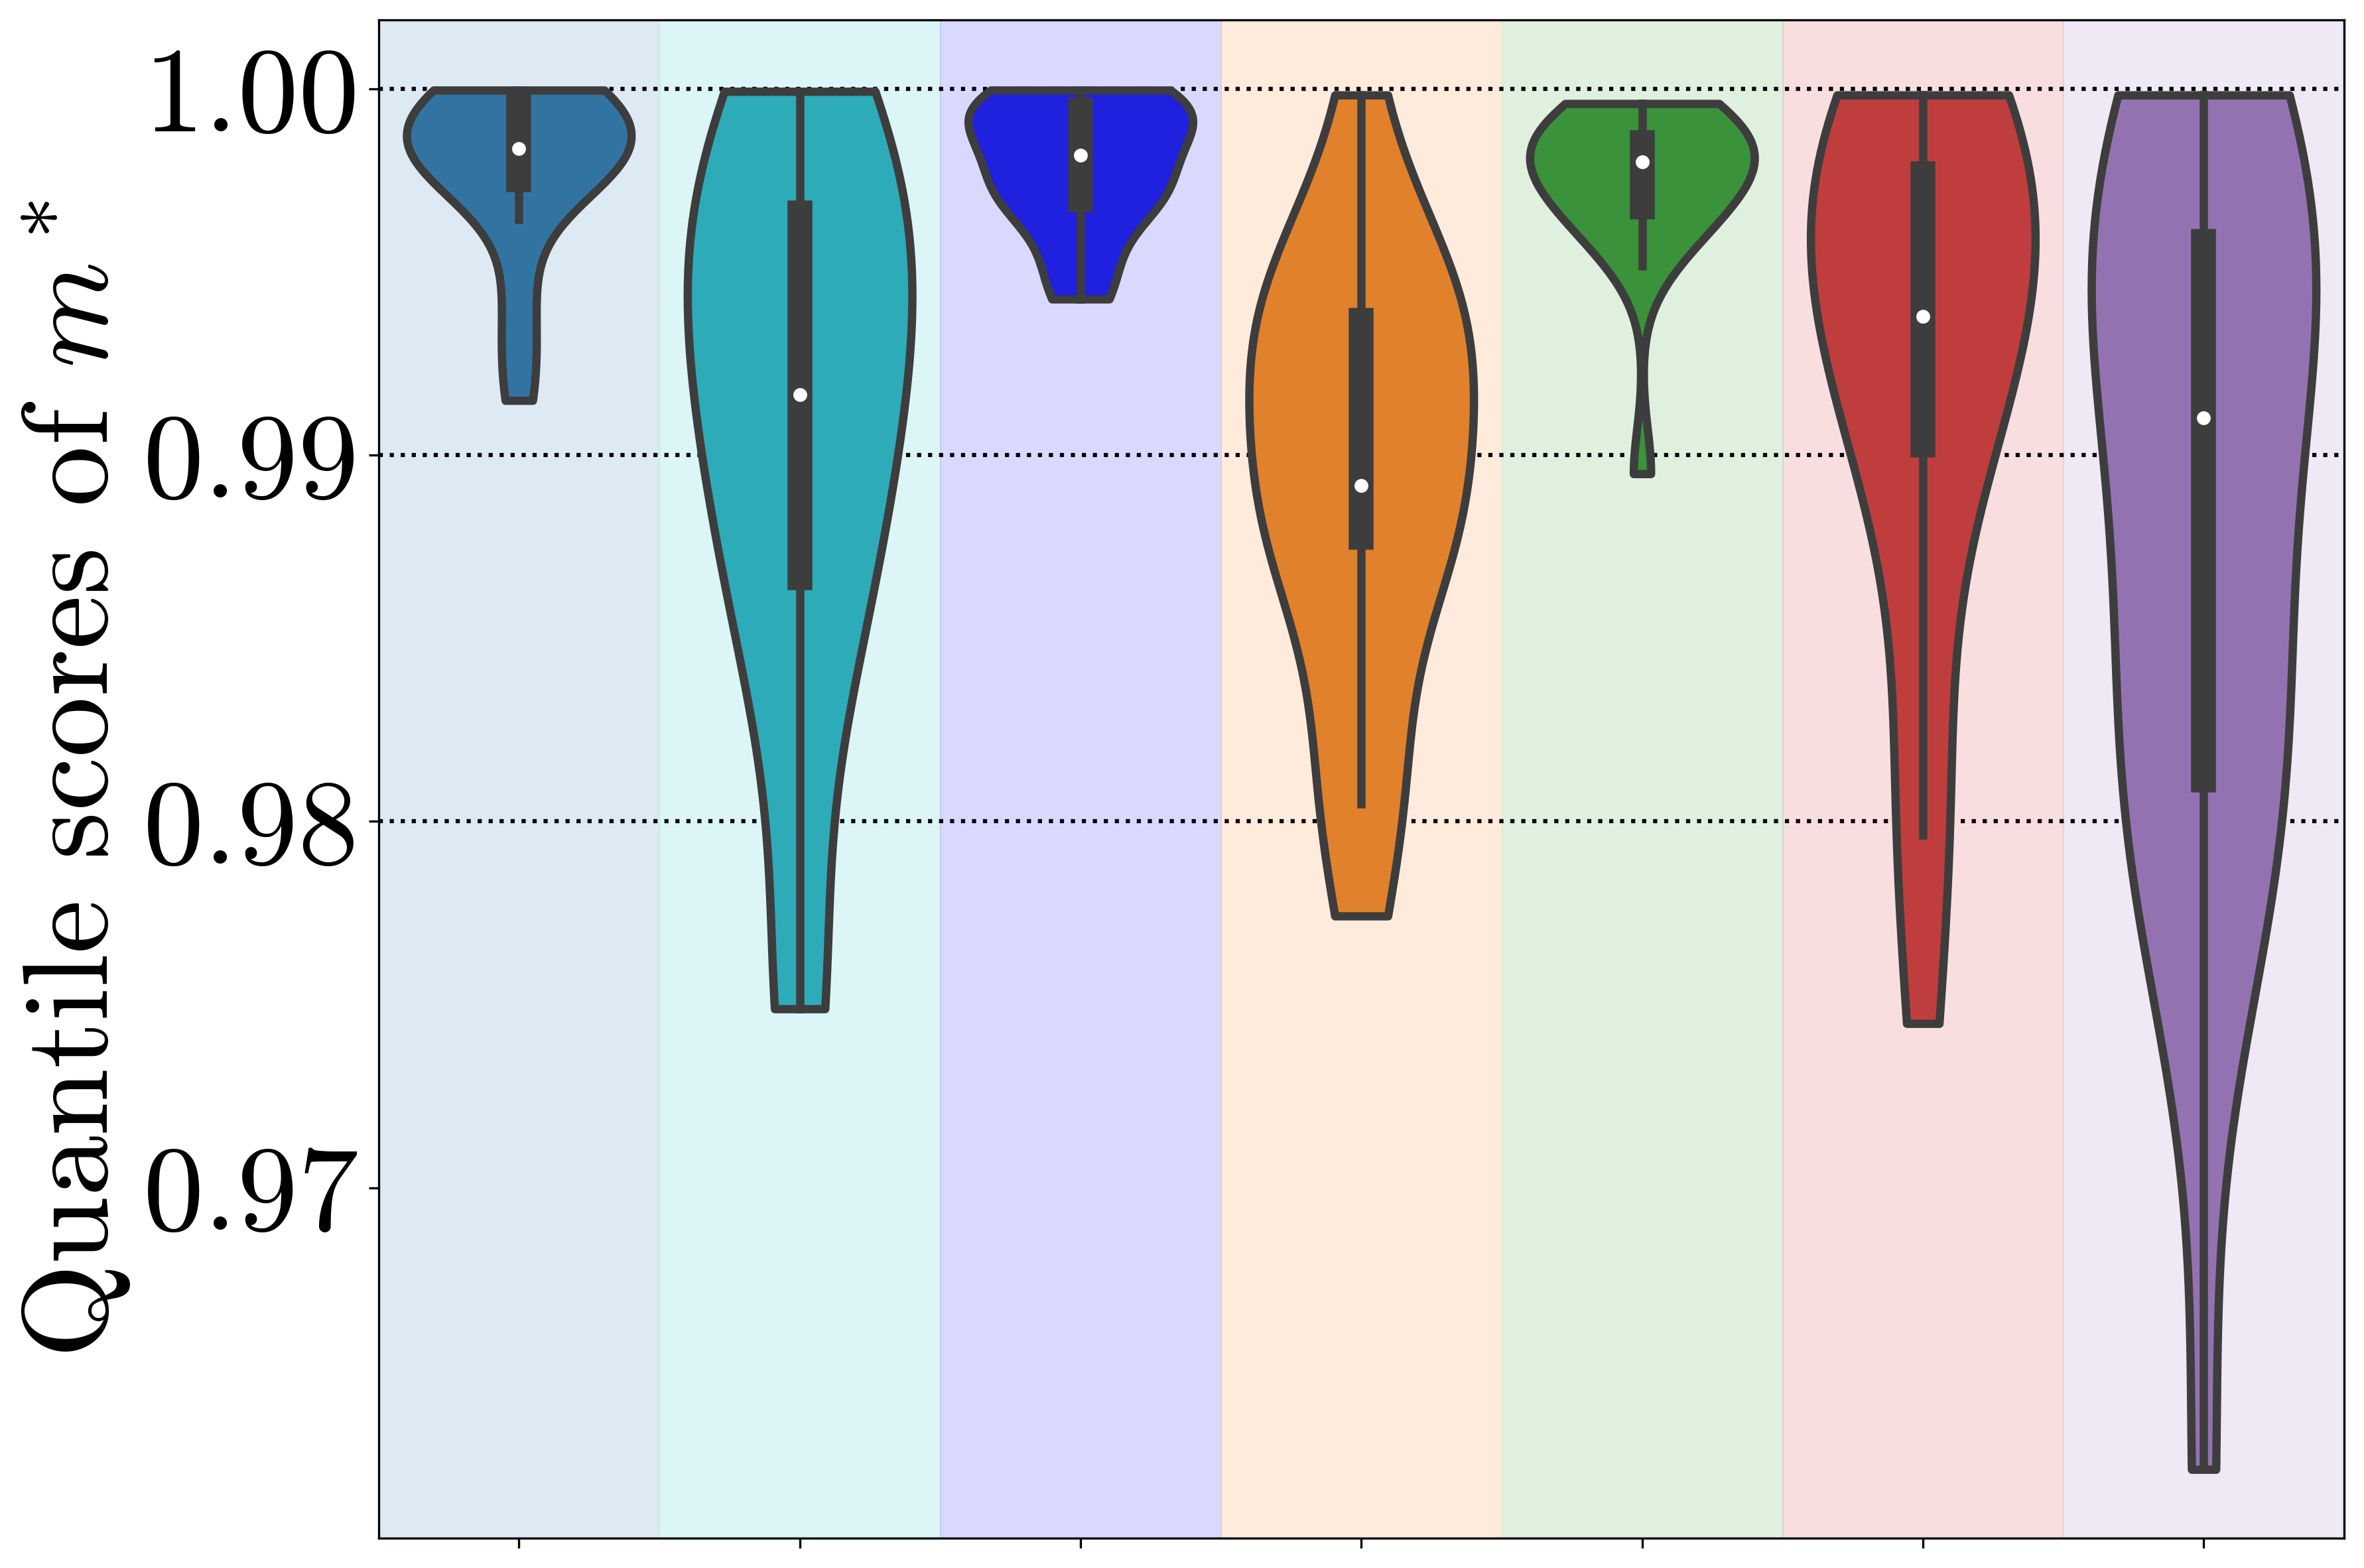

In [29]:
import pandas as pd
import seaborn as sns
sorted_results5 = Res_dict_raw['random']

end = -2




def CQ(results, y):
    y_sorted = np.sort(y)
    quantiles = np.array([stats.percentileofscore(y_sorted, x) / 100 for x in results])
    return quantiles



df = pd.read_csv('../prop_data/MORDRED_SMILES_cep_PCE.csv')

dmin = np.array(df['y1'].to_list()).min()#[df['activity']>=11.]
dmax = np.array(df['y1'].to_list()).max()#[df['activity']>=11.]


sorted_results1 = Res_dict_raw['SAAS']
sorted_results2 = Res_dict_raw['GP_full']
sorted_results3 = Res_dict_raw['GP_PCA']
sorted_results4 = Res_dict_raw['Linear']

y = df['y1'].to_numpy()

df2 = pd.DataFrame()

col_name = r'Quantile scores of $m^* $'

d =  pd.DataFrame({'Method':[names2[0]]*len(seeds), col_name:CQ(sorted_results1[0,:,end],y)})
df2 = pd.concat([df2, d])


d =  pd.DataFrame({'Method':['MolDAIS-CMI']*len(seeds), col_name:CQ(micGP3[:,end+1],y)})
df2 = pd.concat([df2, d])

d =  pd.DataFrame({'Method':['MolDAIS-MIC']*len(seeds), col_name:CQ(micGP2[:,end+1],y)})
df2 = pd.concat([df2, d])


d =  pd.DataFrame({'Method':[names2[1]]*len(seeds), col_name:CQ(sorted_results2[0,:,end],y)})
df2 = pd.concat([df2, d])

d =  pd.DataFrame({'Method':[names2[2]]*len(seeds), col_name:CQ(sorted_results3[0,:,end],y)})
df2 = pd.concat([df2, d])

#d =  pd.DataFrame({'Method':[names2[3]]*len(seeds), 'Final value':(sorted_results4[0,:,end]-dmin)/(dmax-dmin)})
#df2 = pd.concat([df2, d])

d =  pd.DataFrame({'Method':[names2[3]]*len(seeds), col_name:CQ(sorted_results5[0,:,end],y)})
df2 = pd.concat([df2, d])

d =  pd.DataFrame({'Method':['TM-FP']*len(seeds), col_name:CQ(gauche[:,end],y)})
df2 = pd.concat([df2, d])




C = ['tab:blue',

  'tab:cyan',
  'blue',
 'tab:orange',
 'tab:green',
 'tab:red',
 'tab:purple',

         ]

plt.figure(figsize=(13,9))
for i,ls in enumerate(range(7)):
  plt.axvline(i, color=C[i], linestyle='-', zorder=0, linewidth=102, alpha=.15)
plt.axhline(1,color='k', linestyle=':',zorder=0)
plt.axhline(.99,color='k', linestyle=':',zorder=0)
plt.axhline(.98,color='k', linestyle=':',zorder=0)

sns.violinplot(data=df2, x='Method', y=col_name, cut=0, inner="box", scale='width', palette=C, linewidth=3,linecolor='k')
#plt.title('Lipophilicity')
plt.xlabel(None)
#plt.ylim(.93,1.001)
#density_norm{“area”, “count”, “width”}
plt.xticks(visible=False)

plt.tight_layout()
plt.savefig('./figs/cep_finalVals.png')




/home/sorourifar.1/anaconda3/envs/work/lib/python3.8/site-packages/seaborn/distributions.py:1693: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  ax = plt.gca()


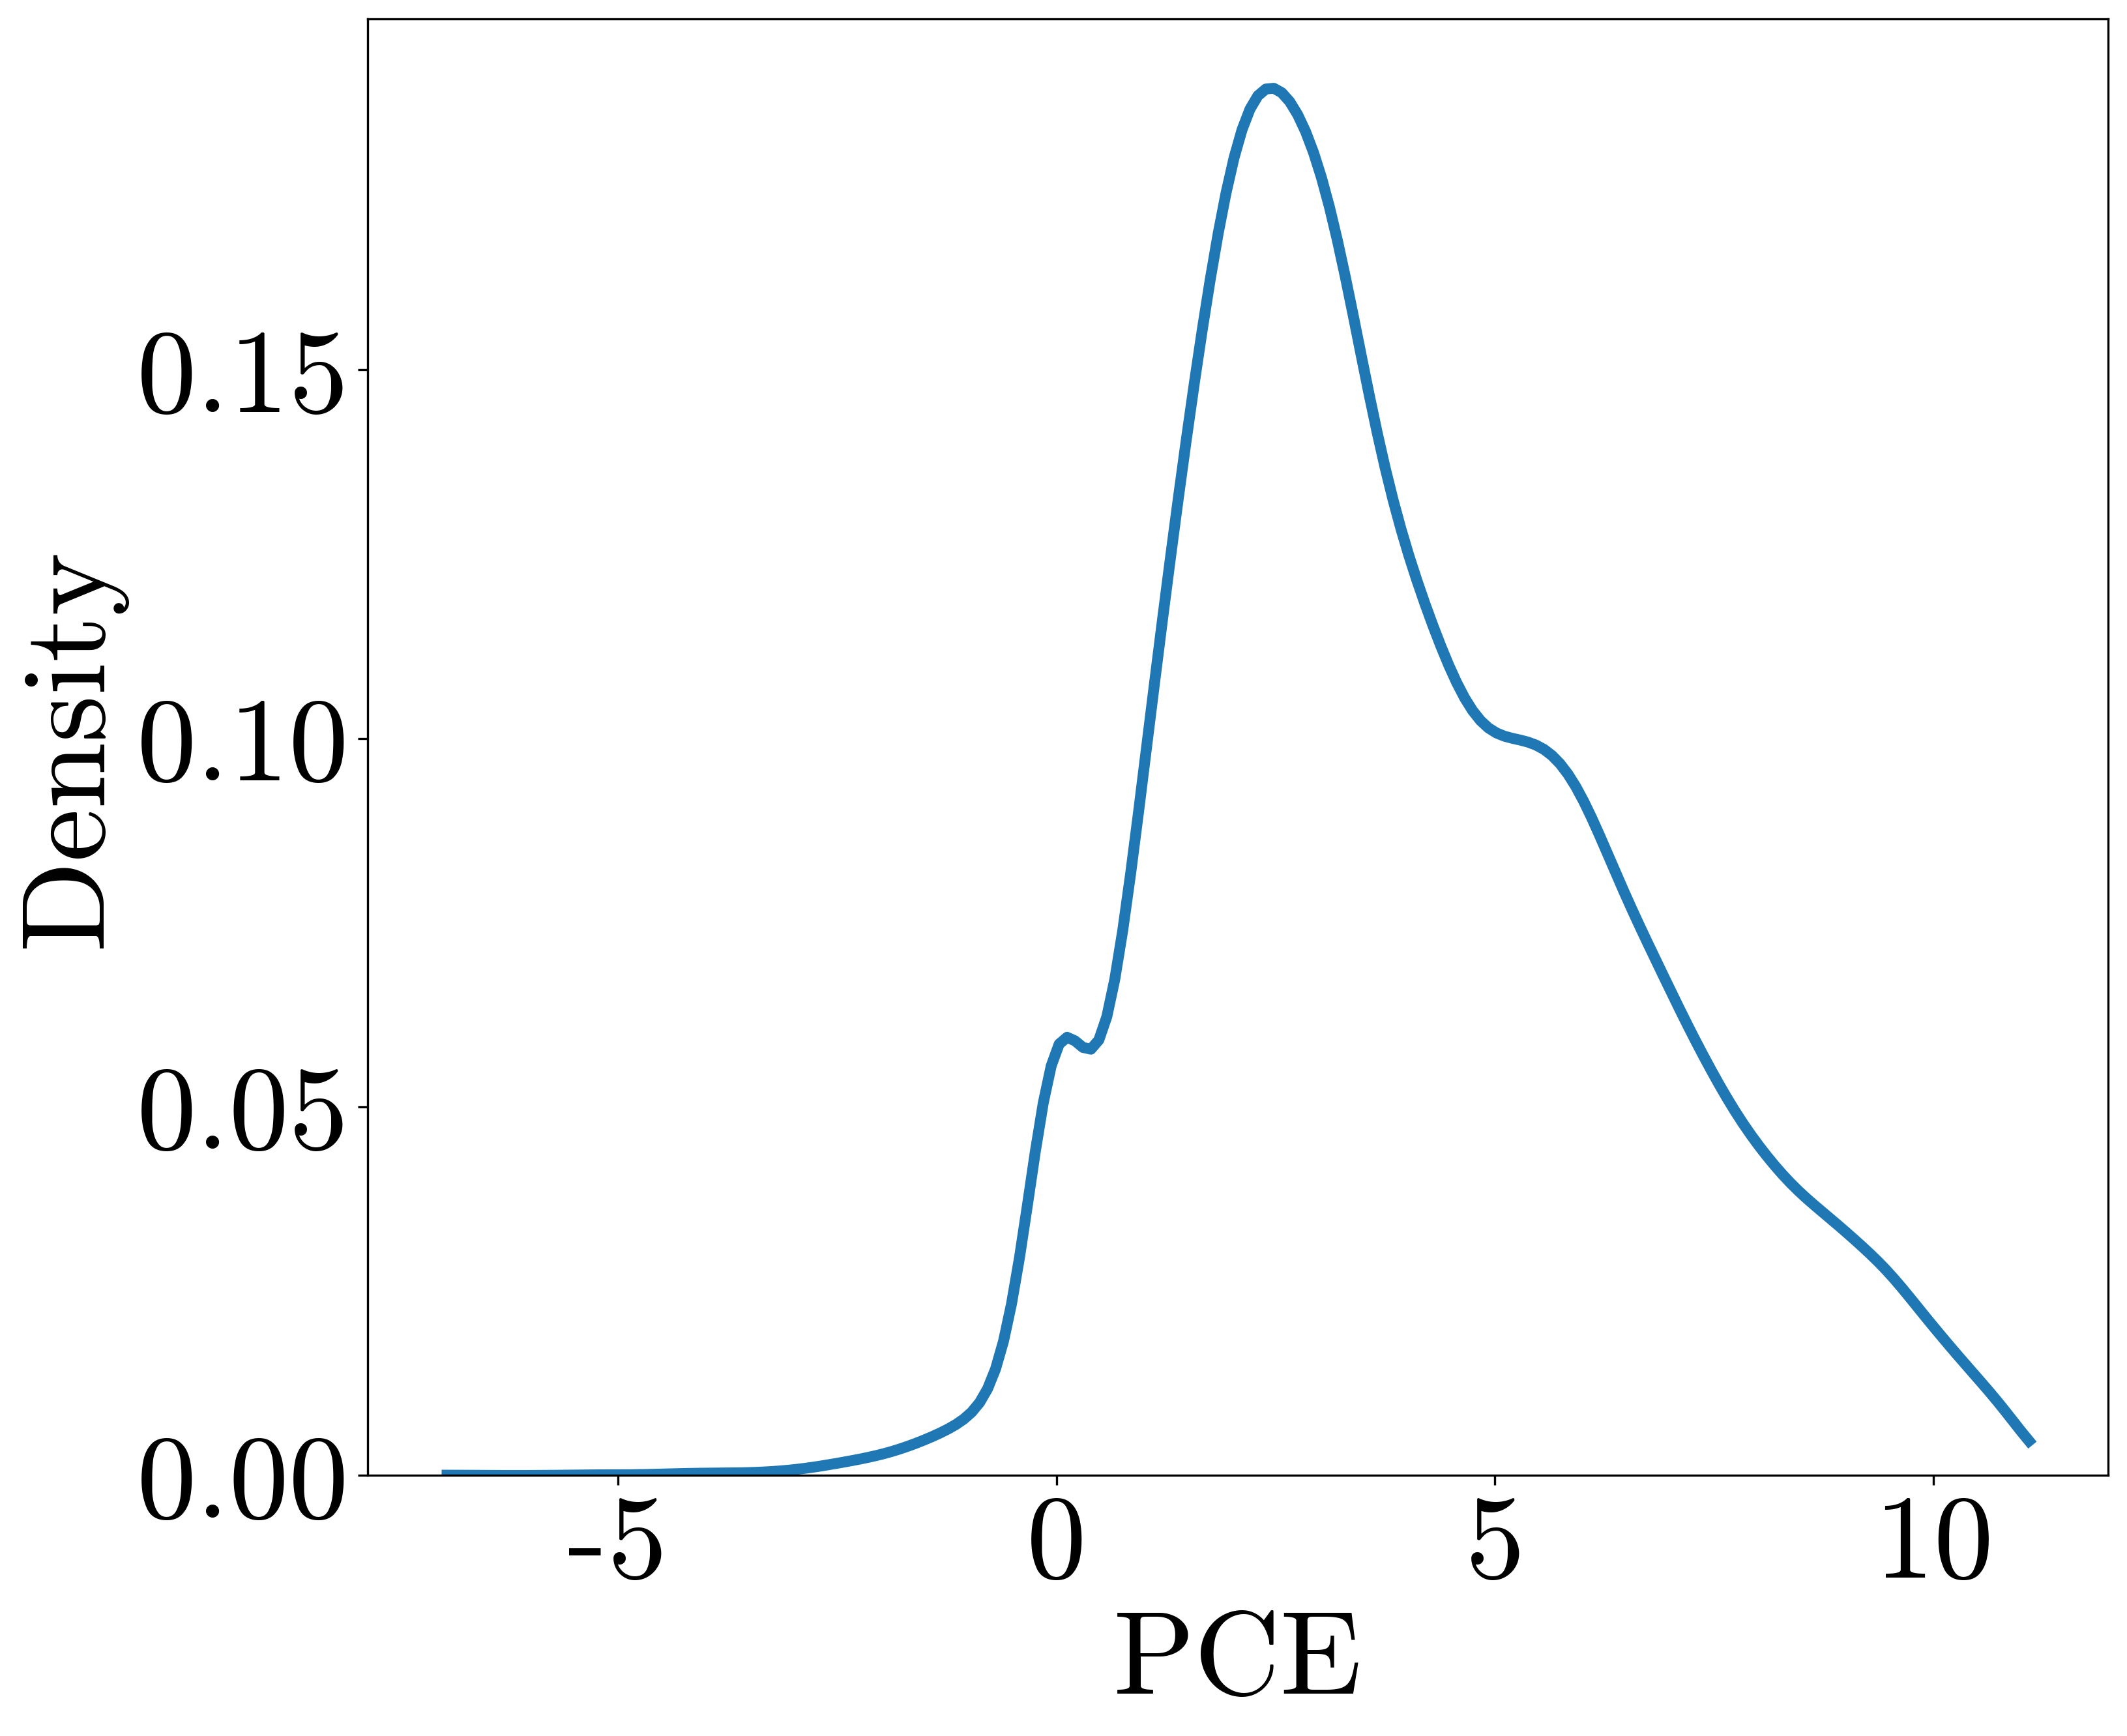

In [231]:
df = pd.read_csv('../prop_data/MORDRED_SMILES_cep_PCE.csv')
plt.figure(figsize=(12,10))
sns.kdeplot(df['y1'], cut=0, linewidth=4)
plt.xlabel('PCE')
plt.tight_layout()

plt.savefig('./figs/cep_density.png')



/tmp/ipykernel_3650194/4230337720.py:1: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.plot(out[1][1:],np.cumsum(out[0])/len(df['y1']) )


(-6.76507987, 11.086613)

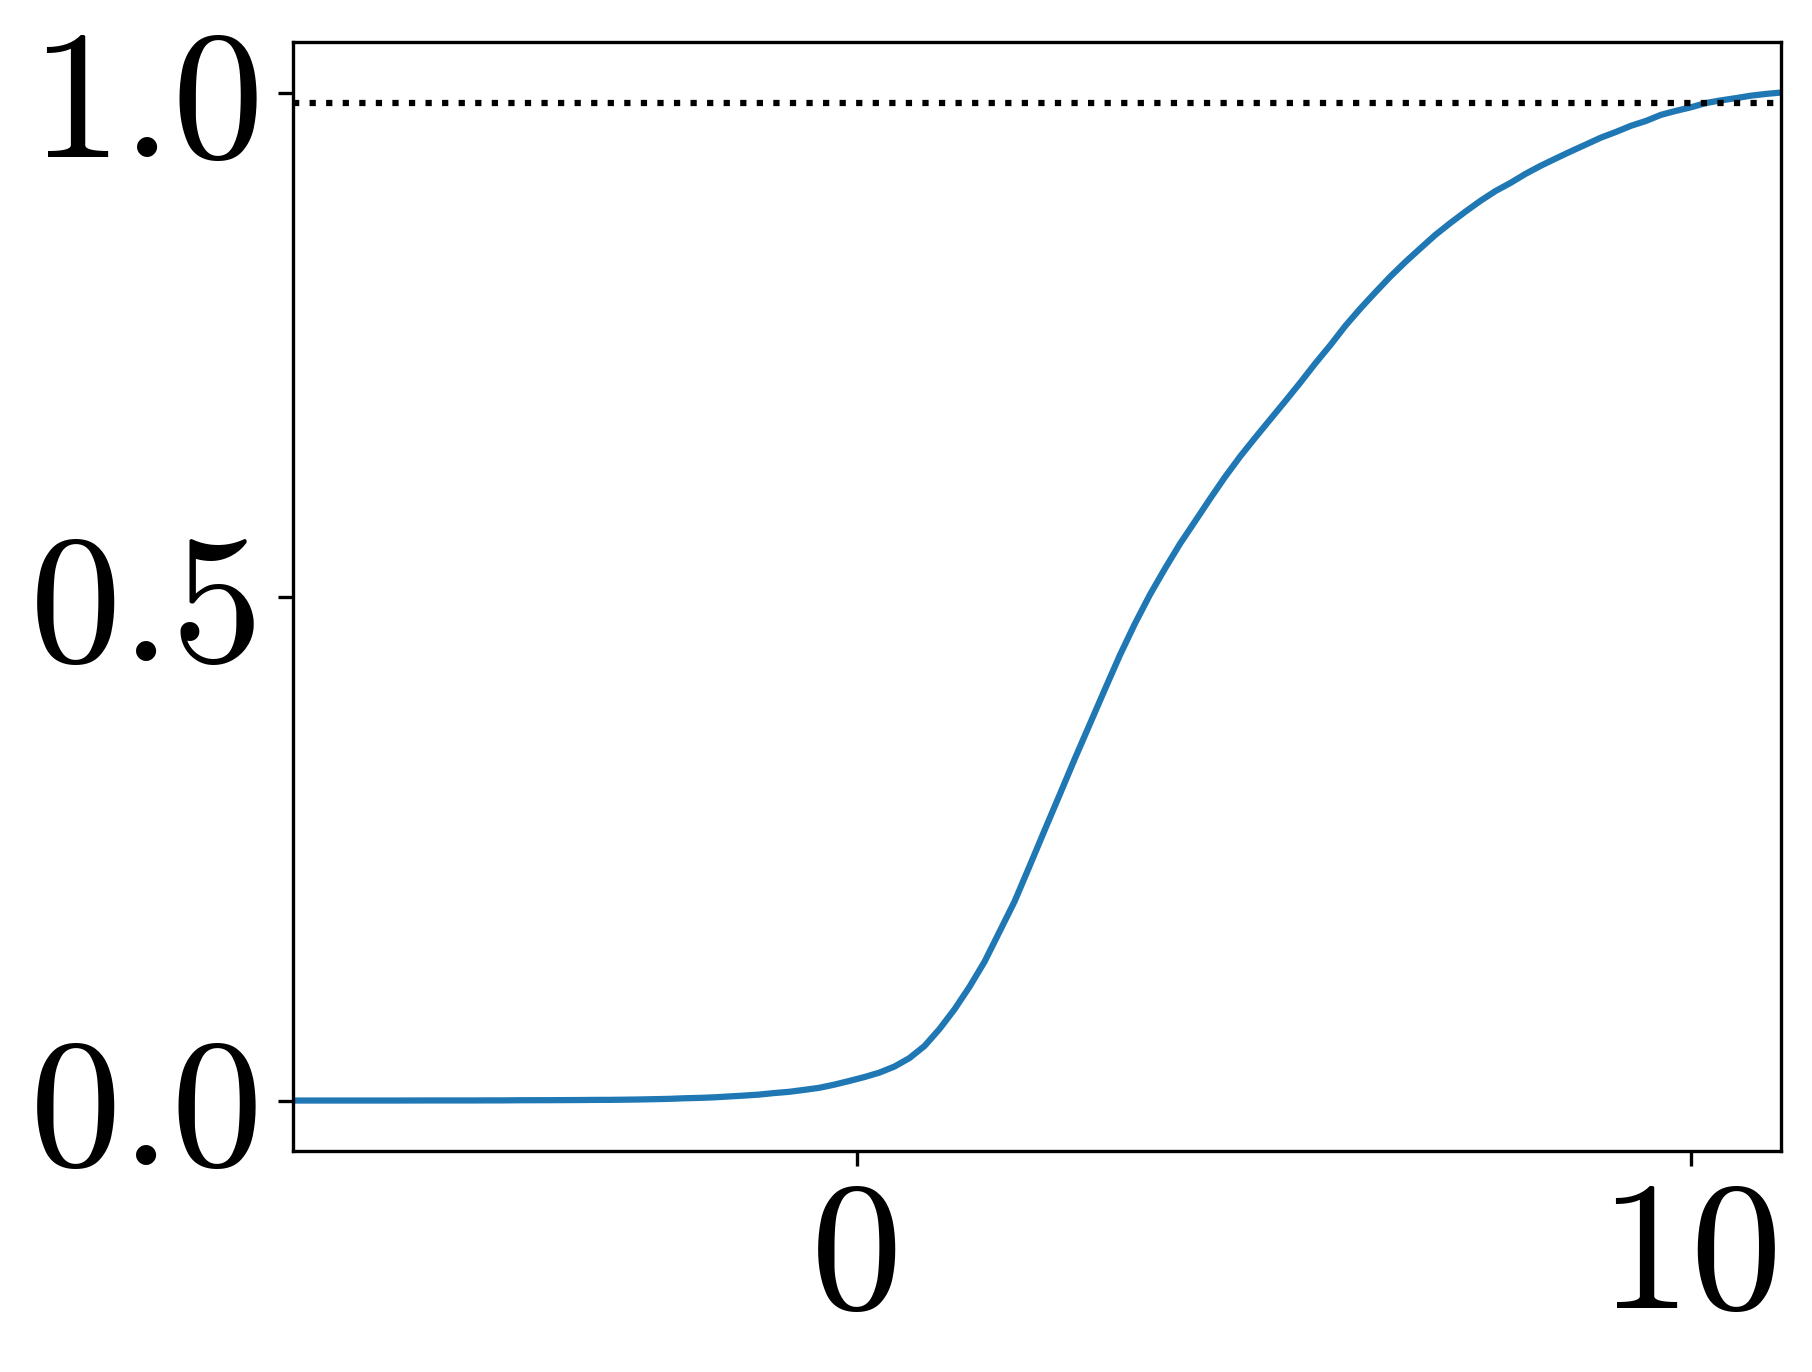

In [48]:
plt.plot(out[1][1:],np.cumsum(out[0])/len(df['y1']) )
plt.plot([out[1][1:].min(), out[1][1:].max()], [.99,.99], 'k:')
plt.xlim(out[1][1:].min(), out[1][1:].max())

In [141]:

name = 'dG'; data_file = 'MORDRED_SMILES_dft_Gsolv.csv'
df_dg = pd.read_csv('./../prop_data/'+data_file)#.drop(columns=['Unnamed: 0'])


name = 'E'; data_file = 'MORDRED_SMILES_dft_E.csv'
df_e0 = pd.read_csv('./../prop_data/'+data_file)#.drop(columns=['Unnamed: 0'])



from rdkit import Chem
from rdkit.Chem import Descriptors
import numpy as np

def compute_molecular_weights(smiles_list):
    molecular_weights = []
    for smiles in smiles_list:
        molecule = Chem.MolFromSmiles(smiles)
        if molecule:
            mw = Descriptors.MolWt(molecule)
            molecular_weights.append(mw)
        else:
            molecular_weights.append(np.nan)  # Use NaN for invalid SMILES
    return np.array(molecular_weights)

smiles_list = df_dg['SMILES'].to_list()
molecular_weights = compute_molecular_weights(smiles_list)


# Step 1: load data
smiles_list = df_dg['SMILES'].to_list()
values1 = -1*torch.tensor(df_dg['Gsolv'].values, dtype=torch.float32).reshape(-1,1)
F = 96485
values2 = torch.tensor(((df_e0['E'].values+0.76)*2*F)/ (3.600*molecular_weights), dtype=torch.float32).reshape(-1,1)



values = torch.cat([values1,values2], dim=1)



/tmp/ipykernel_3650194/2241202817.py:2: DtypeWarning: Columns (140,141,142,149,150,151,158,159,160,167,168,169,176,177,178,185,186,187,194,195,196,203,204,205,212,213,214,221,222,223,230,231,232,347,348,349,356,357,358,365,366,367,374,375,376,383,384,385,392,393,394,401,402,403,410,411,412,419,420,421,428,429,430,437,438,439,446,447,448,454,455,456,462,463,464,470,471,472,478,479,480,486,487,488,494,495,496,502,503,504,510,511,512,518,519,520,526,527,528,534,535,536,542,543,544,550,551,552,558,559,560,566,567,568,574,575,576,582,583,584,590,591,592,598,599,600,606,607,608,614,615,616,622,623,624,630,631,632,638,639,640,832,848) have mixed types. Specify dtype option on import or set low_memory=False.
  df_dg = pd.read_csv('./../prop_data/'+data_file)#.drop(columns=['Unnamed: 0'])
/tmp/ipykernel_3650194/2241202817.py:6: DtypeWarning: Columns (142,143,144,151,152,153,160,161,162,169,170,171,178,179,180,187,188,189,196,197,198,205,206,207,214,215,216,223,224,225,232,233,234,349,350,351,35

In [113]:





moldais_moo = []
sgp_moo  = []
rnd_moo  = []
tmfp_moo = []


for seed in range(10):
    moldais_moo.append( torch.load(f'./mic_res/results/MOO_E_sparsity-CMI10_model-GP_acq-EI_iter_40_seed-{seed}.pkl')['best_values'])
moldais = np.array(moldais_moo)
moldais_m = moldais.mean(axis=0)
moldais_s = moldais.std(axis=0)    
    
    
    
#for seed in range(10):    
#    sgp_moo.append(torch.load(f'./mic_res/results/MOO_E_sparsity-MI10000_model-GP_acq-EI_iter_40_seed-{seed}.pkl')['best_values'])
#sgp = np.array(sgp_moo)
#sgp_m = sgp.mean(axis=0)
#sgp_s = sgp.std(axis=0)        



for seed in range(10):    
    Yi = torch.load(f'./mic_res/results/MOO_E_sparsity-MI10_model-GP_acq-Random_iter_0_seed-{seed}.pkl')['y']
    Y = Yi.prod(1)
    ybest = [Y[:k].max().item() for k in range(10,50)]
    rnd_moo.append(ybest)
rnd = np.array(rnd_moo)
rnd_m = rnd.mean(axis=0)
rnd_s = rnd.std(axis=0)        

    

num_list = []
df_g = pd.read_csv('./mic_res/results/Gauche_MOO.csv')['y1']
for i in range(10):
    str_list = df_g[i].replace('\n','').replace('tensor([','').replace('Tensor([','').replace('       ','').replace('],dtype=torch.float64)','').replace('], dtype=torch.float64)','').replace(')','').split(', ')
    num_list.append( np.array([float(x.replace(']', '')) for x in str_list]) )
gauche = np.array(num_list)[:,:40]
gauche_m = gauche.mean(axis=0)
gauche_s = gauche.std(axis=0)

/tmp/ipykernel_3650194/273344317.py:3: UserWarning: cmr10 font should ideally be used with mathtext, set axes.formatter.use_mathtext to True
  plt.plot([0,41], [hv.max(),hv.max()], 'k:'  )


Text(0, 0.5, '$-\\Delta G \\cdot E^o$')

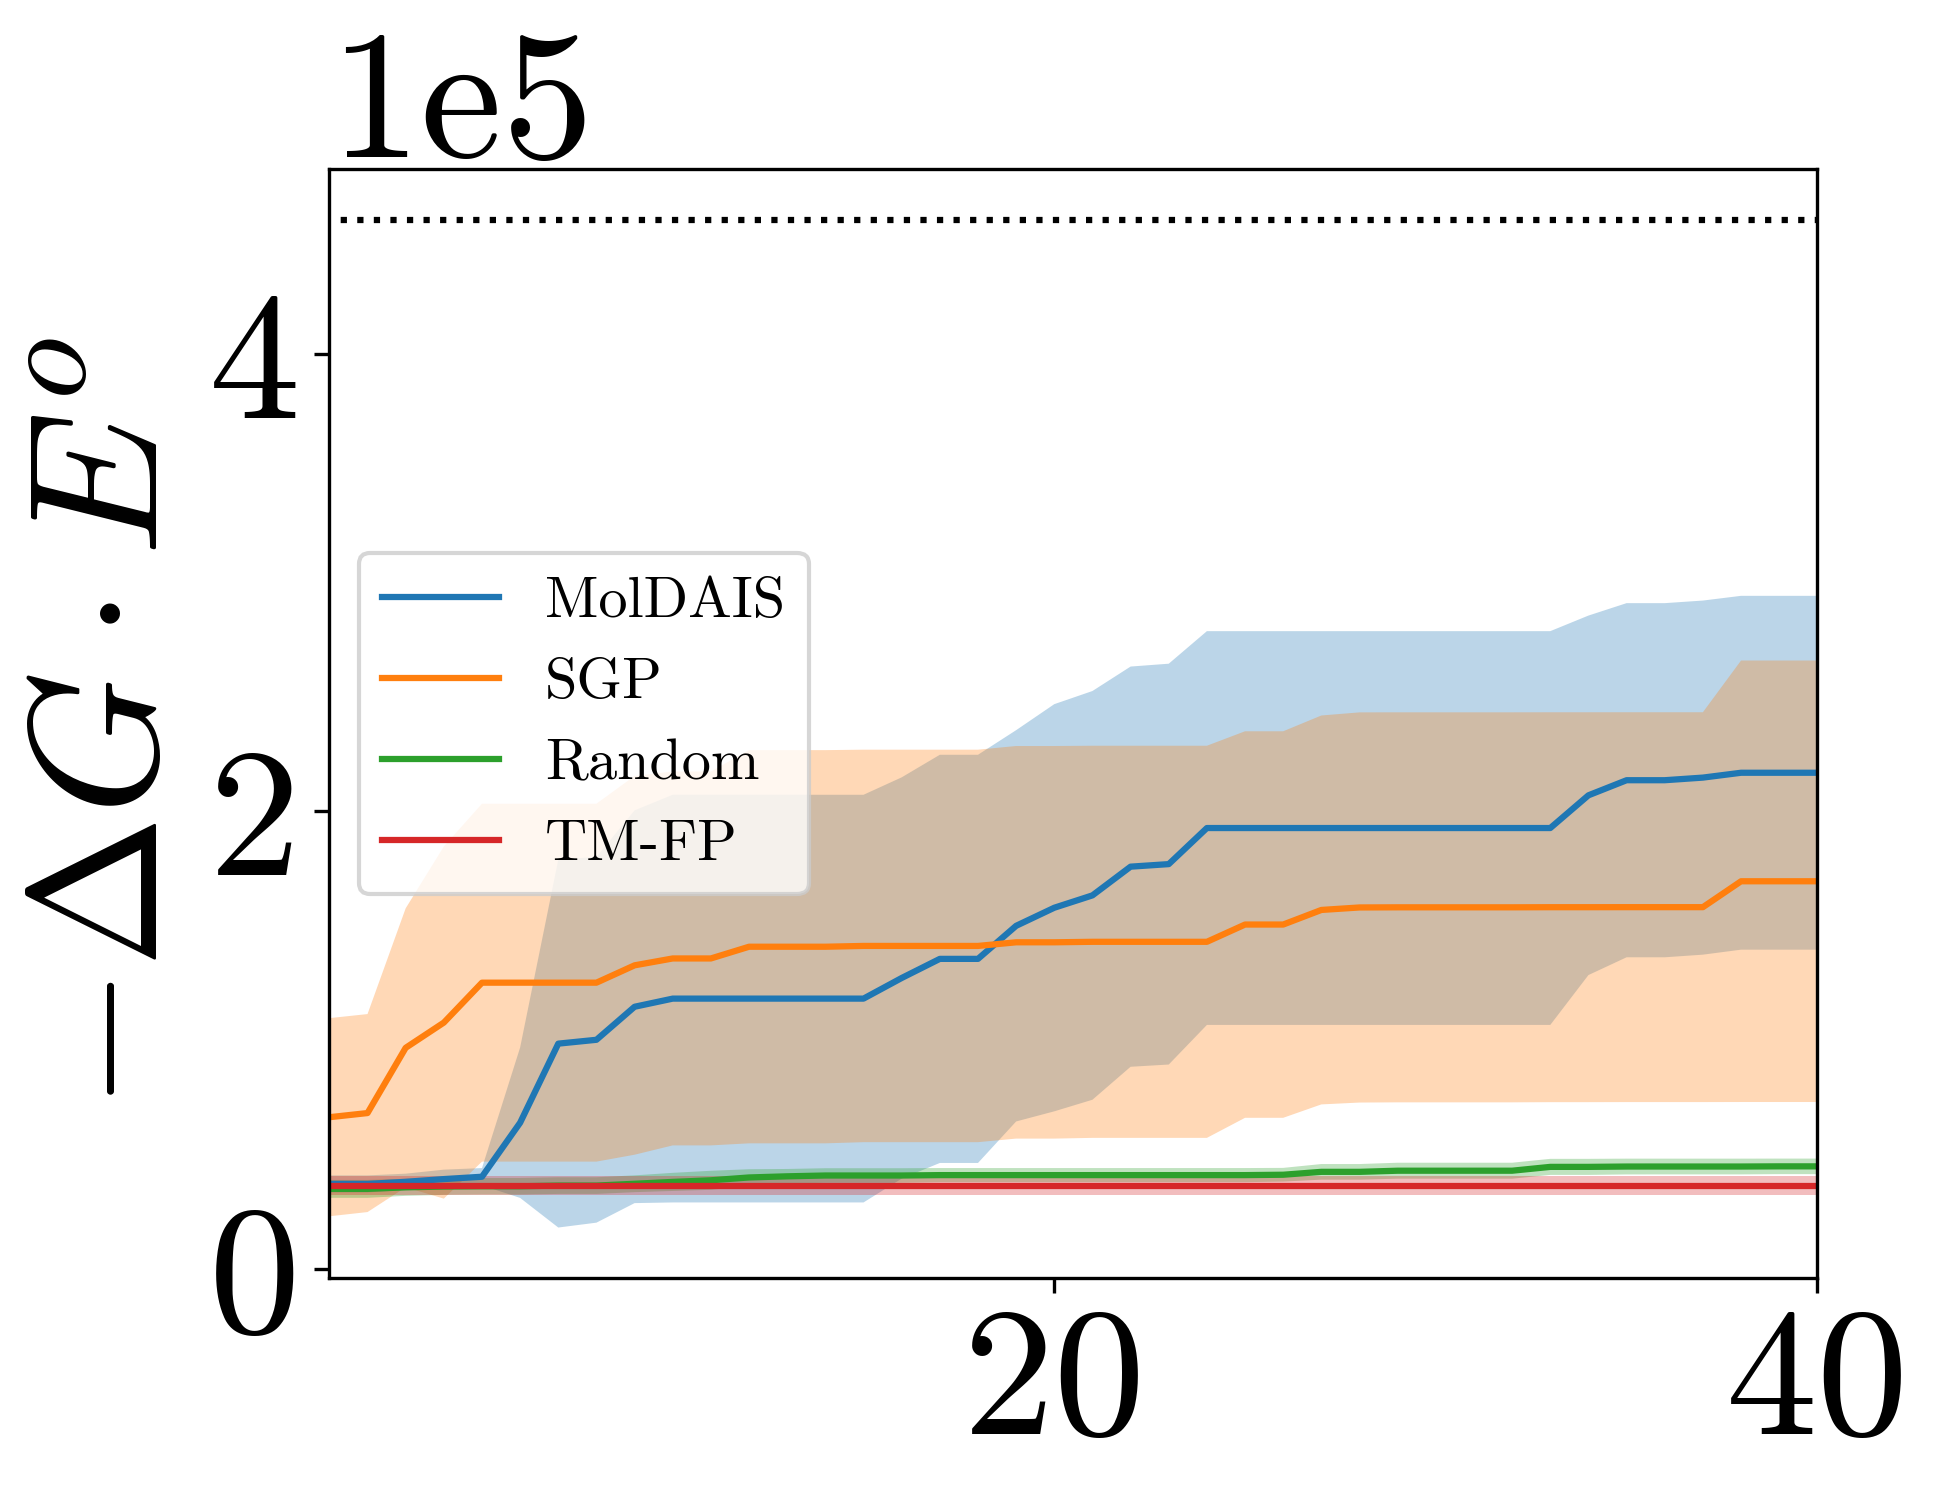

In [226]:
Y = values
hv = Y[:,1]*Y[:,0]
plt.plot([0,41], [hv.max(),hv.max()], 'k:'  )

plt.plot(np.arange(1,41), moldais_m, label='MolDAIS')
plt.fill_between(np.arange(1,41),moldais_m+1.95*moldais_s/10**0.5,moldais_m-1.95*moldais_s/10**0.5, alpha=.3)

plt.plot(np.arange(1,41), sgp_m, label='SGP')
plt.fill_between(np.arange(1,41),sgp_m+1.95*sgp_s/10**0.5,sgp_m-1.95*sgp_s/10**0.5, alpha=.3)

plt.plot(np.arange(1,41), rnd_m, label='Random')
plt.fill_between(np.arange(1,41),rnd_m+1.95*rnd_s/10**0.5,rnd_m-1.95*rnd_s/10**0.5, alpha=.3)


plt.plot(np.arange(1,41),gauche_m, label='TM-FP')
plt.fill_between(np.arange(1,41),gauche_m+1.95*gauche_s/10**0.5,gauche_m-1.95*gauche_s/10**0.5, alpha=.3)



plt.ticklabel_format(axis='y', style='sci', scilimits=(0,0))

#plt.yscale('exp')
#plt.ylim(0)
plt.xlim(1,40)
plt.legend(fontsize=14, ncols = 1, )
plt.ylabel(r"$-\Delta G \cdot E^o$")






